# Trabajo de Fin de Grado: Desarrollo y Evaluación de un Método Cuántico de Selección de Características

## Notebook 04 - Fase 4: Creación y Auditoría de Splits

Esta fase crea las particiones `train`, `validation` y `test` que utilizarán las fases posteriores. El objetivo no es entrenar modelos finales ni seleccionar variables, sino comprobar que las particiones conservan el problema original sin solapes, pérdidas de clases, drift evidente o señales de leakage.

La fase se plantea como una comprobación de representatividad antes de construir modelos: cada fila debe pertenecer a una única partición, las clases del target deben seguir presentes en los tres subconjuntos y las distribuciones de las variables no deben mostrar cambios que comprometan la comparación posterior entre métodos de selección de características.

Este notebook fija una condición experimental compartida para el contraste final del TFG. Según la propuesta oficial, el objetivo 5 exige comparar el método cuántico frente a los mejores métodos clásicos; por tanto, los mismos splits `train`/`validation`/`test` servirán al brazo clásico y al método QFS sobre átomos neutros. En los trabajos QFS del proyecto, la relevancia se codifica mediante información mutua con el target, la redundancia mediante información mutua entre variables traducida a distancias atómicas vía MDS y el objetivo `Q(x; alfa)` favorece subconjuntos compactos, especialmente en rangos pequeños de características. Por eso el rigor en drift, leakage y validación adversarial no es un trámite: protege la comparación final contra diferencias de particionado que podrían confundirse con una ventaja clásica o cuántica.


## Importación de Librerías

Se utilizan herramientas estándar de `pandas`, `scipy`, `scikit-learn` y `matplotlib` para cargar datos, crear particiones estratificadas, contrastar estabilidad estadística y representar los resultados de auditoría.


In [1]:
from pathlib import Path
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, ks_2samp, wasserstein_distance
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import normalized_mutual_info_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)


## Definición de Rutas y Directorios de Salida

Se fijan las rutas de entrada y salida. Al iniciar la fase se limpian las salidas anteriores de Fase 4 para que no queden tablas, figuras o informes de versiones previas.


In [2]:
# Rutas principales del proyecto.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
PHASE3_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "03_postprocessing_audit"
PHASE4_TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "04_split_audit"
PHASE4_FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "04_split_audit"
PHASE4_REPORTS_DIR = PROJECT_ROOT / "results" / "reports" / "04_split_audit"

for output_dir in [SPLITS_DIR, PHASE4_TABLES_DIR, PHASE4_FIGURES_DIR, PHASE4_REPORTS_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

for old_path in PHASE4_TABLES_DIR.rglob("*.csv"):
    old_path.unlink()

for old_path in PHASE4_FIGURES_DIR.rglob("*"):
    if old_path.suffix.lower() in {".png", ".pdf"}:
        old_path.unlink()

for old_path in PHASE4_FIGURES_DIR.rglob("*.png"):
    old_path.unlink()

for old_path in PHASE4_REPORTS_DIR.rglob("*"):
    if old_path.is_file() and old_path.suffix.lower() in {".md", ".tex", ".png"}:
        old_path.unlink()


La inicialización fija las entradas procesadas y prepara los destinos de trabajo de la fase. La limpieza inicial garantiza que las tablas y figuras exportadas al final correspondan a una única ejecución reproducible.


## Configuración Visual y Parámetros Generales

El split base es 70/15/15 y se estratifica por target cuando las clases lo permiten. La semilla fija hace reproducible la asignación de filas y facilita que las fases posteriores trabajen siempre con los mismos subconjuntos.

Los parámetros `MAX_SAMPLE_PCA`, `MAX_SAMPLE_ADVERSARIAL` y `MAX_SAMPLE_LEAKAGE` son límites computacionales: reducen el coste de diagnósticos exploratorios cuando un dataset es grande, pero no cambian las particiones guardadas. Los valores se fijan por el mayor coste esperado en `customer_churn` y mantienen miles de observaciones por diagnóstico, suficiente para lectura exploratoria reproducible sin convertir la auditoría en un entrenamiento pesado.

Los umbrales `PSI_REVIEW_THRESHOLD`, `KS_REVIEW_THRESHOLD` y `WASSERSTEIN_REVIEW_THRESHOLD` son criterios de revisión exploratoria, alineados con la auditoría distributiva de Fase 3 para mantener escalas comparables entre fases. No son reglas universales de descarte. `AUC_LEAKAGE_REVIEW_THRESHOLD` y `NMI_LEAKAGE_REVIEW_THRESHOLD` se fijan en 0.99 porque solo interesan proxies casi deterministas del target; valores más bajos se interpretarán con el resto de métricas, no como leakage confirmado.


In [3]:
RANDOM_STATE = 2026
TRAIN_PCT = 0.70
VALIDATION_PCT = 0.15
TEST_PCT = 0.15
MAX_SAMPLE_PCA = 6000
MAX_SAMPLE_ADVERSARIAL = 12000
MAX_SAMPLE_LEAKAGE = 12000
MAX_PCA_COMPONENTS = 5

PSI_REVIEW_THRESHOLD = 0.10
KS_REVIEW_THRESHOLD = 0.10
WASSERSTEIN_REVIEW_THRESHOLD = 0.20
AUC_LEAKAGE_REVIEW_THRESHOLD = 0.99
NMI_LEAKAGE_REVIEW_THRESHOLD = 0.99

SPLIT_ORDER = ["train", "validation", "test"]

SOURCE_DATASETS = {
    "breast_cancer_wisconsin": "breast_cancer_wisconsin",
    "customer_churn": "customer_churn",
    "madelon": "madelon",
    "olive_oil_3class": "olive_oil",
    "olive_oil_9class": "olive_oil",
}

TARGET_BY_DATASET = {
    "breast_cancer_wisconsin": "target",
    "customer_churn": "target",
    "madelon": "target",
    "olive_oil_3class": "area",
    "olive_oil_9class": "target",
}

EXCLUDED_BY_DATASET = {
    "breast_cancer_wisconsin": [],
    "customer_churn": [],
    "madelon": [],
    "olive_oil_3class": ["target", "palmitic"],
    "olive_oil_9class": ["area", "palmitic"],
}

DATASET_ORDER = list(SOURCE_DATASETS)
DATASET_LABELS = {
    "breast_cancer_wisconsin": "Breast Cancer Wisconsin",
    "customer_churn": "Customer Churn",
    "madelon": "Madelon",
    "olive_oil_3class": "Olive Oil 3 Clases",
    "olive_oil_9class": "Olive Oil 9 Clases",
}

SPLIT_COLORS = {"train": "#2F6F9F", "validation": "#D9822B", "test": "#5E8C61"}

plt.rcParams.update({
    "figure.facecolor": "#FAF7F2",
    "axes.facecolor": "#FAF7F2",
    "axes.edgecolor": "#D8D0C4",
    "axes.labelcolor": "#2D2A26",
    "text.color": "#2D2A26",
    "xtick.color": "#2D2A26",
    "ytick.color": "#2D2A26",
    "grid.color": "#E6DED2",
    "font.size": 10,
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 90)


## Utilidades Generales del Notebook

Las siguientes funciones guardan tablas, muestran salidas, exportan figuras y mantienen un formato visual común. Son utilidades transversales; las funciones analíticas se definen en la sección donde se usan.


In [4]:
def guardar_tabla(tabla, nombre_archivo):
    ruta_tabla = PHASE4_TABLES_DIR / nombre_archivo
    tabla.to_csv(ruta_tabla, index=False)
    return ruta_tabla


COLUMNAS_LECTURA = {
    "dataset": "Dataset",
    "fuente": "Fuente",
    "filas": "Filas",
    "columnas": "Columnas",
    "target": "Variable objetivo",
    "target_presente": "Objetivo presente",
    "clases_target": "Clases objetivo",
    "features_potenciales": "Predictoras potenciales",
    "nmi_area_target": "NMI area-target",
    "nmi_palmitic_target": "NMI palmitic-objetivo",
    "max_valores_palmitic_por_clase": "Máximo valores palmitic por clase",
    "variable": "Variable",
    "rol": "Rol",
    "tipo": "Tipo",
    "excluida": "Excluida de X",
    "motivo_exclusion": "Motivo de exclusión",
    "predictoras": "Predictoras",
    "categoricas": "Categóricas",
    "numericas": "Numéricas",
    "target_en_X": "Objetivo dentro de X",
    "variable_excluida": "Variable excluida",
    "nmi_con_target": "NMI con objetivo",
    "auc_univariante": "AUC univariante",
    "split": "Partición",
    "proporcion": "Proporción",
    "estratificado": "Estratificado",
    "random_state": "Semilla",
    "filas_train": "Filas train",
    "filas_validation": "Filas validación",
    "filas_test": "Filas test",
    "original_index": "Índice original",
    "indice_min": "Índice mínimo",
    "indice_max": "Índice máximo",
    "n": "N",
    "x_rows": "Filas X",
    "y_rows": "Filas y",
    "same_index": "Mismo índice",
    "same_columns": "Mismas columnas",
    "index_overlap": "Solape de índice",
    "row_hash_overlap": "Solape de filas",
    "duplicados_X": "Duplicados en X",
    "clase": "Clase",
    "conteo": "Conteo",
    "proporcion_train": "Proporción train",
    "proporcion_validation": "Proporción validación",
    "proporcion_test": "Proporción test",
    "max_delta_proporcion": "Delta máximo de proporción",
    "comparacion": "Comparación",
    "chi2": "Chi-cuadrado",
    "p_value": "p-valor",
    "min_expected": "Esperado mínimo",
    "ks_stat": "Estadístico KS",
    "ks_pvalue": "p-valor KS",
    "wasserstein": "Distancia Wasserstein",
    "psi": "PSI",
    "drift_score": "Puntuación de drift",
    "drift_flag": "Revisión por drift",
    "variables_con_flag": "Variables en revisión",
    "max_psi": "PSI máximo",
    "max_distancia": "Distancia máxima",
    "pc1": "CP1",
    "pc2": "CP2",
    "componente": "Componente",
    "varianza_explicada": "Varianza explicada",
    "varianza_acumulada": "Varianza acumulada",
    "pc1_media": "Media CP1",
    "pc2_media": "Media CP2",
    "variables_numericas": "Variables numéricas",
    "variables_categoricas": "Variables categóricas",
    "nmi_ge_099": "Variables con NMI >= 0,99",
    "nombres_sospechosos": "Nombres sospechosos",
    "muestras_usadas": "Muestras usadas",
    "auc_cv": "AUC medio",
    "auc_fold_std": "Desviación AUC",
    "fold": "Fold",
    "auc": "AUC",
    "index_overlap_total": "Solape total de índice",
    "row_hash_overlap_total": "Solape total de filas",
}


def mostrar_tabla(tabla, nombre=None, n=10):
    if nombre is not None:
        display(Markdown(f"**{nombre}** - {tabla.shape[0]} filas, {tabla.shape[1]} columnas."))
    tabla_lectura = tabla.head(n).rename(columns=COLUMNAS_LECTURA)
    display(tabla_lectura)


def guardar_figura(figura, nombre_archivo):
    ruta_png = PHASE4_FIGURES_DIR / nombre_archivo
    ruta_pdf = ruta_png.with_suffix(".pdf")
    figura.savefig(ruta_png, dpi=300, bbox_inches="tight")
    figura.savefig(ruta_pdf, bbox_inches="tight")
    return ruta_png, ruta_pdf


def aplicar_estilo_eje(eje, eje_rejilla="x"):
    eje.spines["top"].set_visible(False)
    eje.spines["right"].set_visible(False)
    eje.grid(axis=eje_rejilla, alpha=0.65)
    eje.set_axisbelow(True)


In [5]:
def obtener_info_texto(datos_dataset):
    salida_info = io.StringIO()
    datos_dataset.info(buf=salida_info)
    return salida_info.getvalue()


def etiqueta_dataset(nombre_dataset):
    return DATASET_LABELS.get(nombre_dataset, nombre_dataset.replace("_", " ").title())


## 4.1 Carga de Datasets Procesados y Formulaciones Operativas

Se cargan los datasets procesados de Fase 3 y se confirma que las tablas estadísticas previas estén disponibles antes de crear particiones nuevas. `olive_oil` se evalúa en dos formulaciones porque `docs/decisions/fase4_olive_oil_formulations.md` documenta dos tareas supervisadas trazables: `olive_oil_3class`, con `area` como target de 3 clases, y `olive_oil_9class`, con `target` como etiqueta regional de 9 clases. La columna `palmitic` se audita como proxy porque toma un único valor por región; por eso se excluye de ambas formulaciones antes del split. El resultado se lee verificando filas, columnas, clases y variables excluidas, no comparando rendimiento todavía.


In [6]:
phase3_table_names = [
    "fase3_resumen_metricas_split.csv",
    "fase3_target_resumen.csv",
    "fase3_dimensionalidad_final.csv",
    "fase3_correlaciones_resumen.csv",
]

for table_name in phase3_table_names:
    table_path = PHASE3_TABLES_DIR / table_name
    assert table_path.exists()


Las 4 tablas estadísticas de Fase 3 están disponibles, incluida la dimensionalidad final y el resumen de target. Esa base previa permite crear splits sobre datos ya procesados y auditados, sin reabrir decisiones de limpieza en esta fase.


In [7]:
def cargar_dataset_procesado(nombre_fuente):
    ruta_dataset = PROCESSED_DATA_DIR / f"{nombre_fuente}_processed.csv"
    if not ruta_dataset.exists():
        raise FileNotFoundError(f"No existe el dataset procesado: {ruta_dataset}")
    return pd.read_csv(ruta_dataset)


def resumir_carga_operativa(nombre_dataset):
    datos_dataset = datos_operativos[nombre_dataset]
    target_name = TARGET_BY_DATASET[nombre_dataset]
    return {
        "dataset": nombre_dataset,
        "fuente": SOURCE_DATASETS[nombre_dataset],
        "filas": len(datos_dataset),
        "columnas": datos_dataset.shape[1],
        "target": target_name,
        "target_presente": target_name in datos_dataset.columns,
        "clases_target": datos_dataset[target_name].nunique(dropna=True),
        "features_potenciales": datos_dataset.shape[1] - 1,
    }


In [8]:
def calcular_nmi_columnas(datos_dataset, variable_a, variable_b):
    return normalized_mutual_info_score(datos_dataset[variable_a].astype(str), datos_dataset[variable_b].astype(str))


def resumir_formulaciones_olive_oil():
    datos_olive = datos_fuente["olive_oil"]
    return pd.DataFrame([crear_fila_formulacion_olive(nombre_dataset, datos_olive) for nombre_dataset in ["olive_oil_3class", "olive_oil_9class"]])


def crear_fila_formulacion_olive(nombre_dataset, datos_olive):
    target_name = TARGET_BY_DATASET[nombre_dataset]
    return {
        "dataset": nombre_dataset,
        "target": target_name,
        "clases_target": datos_olive[target_name].nunique(dropna=True),
        "nmi_area_target": calcular_nmi_columnas(datos_olive, "area", "target"),
        "nmi_palmitic_target": calcular_nmi_columnas(datos_olive, "palmitic", target_name),
        "max_valores_palmitic_por_clase": datos_olive.groupby(target_name)["palmitic"].nunique().max(),
    }


In [9]:
datos_fuente = {
    "breast_cancer_wisconsin": cargar_dataset_procesado("breast_cancer_wisconsin"),
    "customer_churn": cargar_dataset_procesado("customer_churn"),
    "madelon": cargar_dataset_procesado("madelon"),
    "olive_oil": cargar_dataset_procesado("olive_oil"),
}

datos_operativos = {
    nombre_dataset: datos_fuente[nombre_fuente].copy()
    for nombre_dataset, nombre_fuente in SOURCE_DATASETS.items()
}

resumen_carga = pd.DataFrame([resumir_carga_operativa(nombre_dataset) for nombre_dataset in DATASET_ORDER])
formulaciones_olive_oil = resumir_formulaciones_olive_oil()

guardar_tabla(resumen_carga, "fase4_carga_datasets.csv")
guardar_tabla(formulaciones_olive_oil, "fase4_formulaciones_olive_oil.csv")
mostrar_tabla(resumen_carga, "Carga de datasets operativos", n=10)
mostrar_tabla(formulaciones_olive_oil, "Métricas de formulaciones Olive Oil", n=10)


**Carga de datasets operativos** - 5 filas, 8 columnas.

,Dataset,Fuente,Filas,Columnas,Variable objetivo,Objetivo presente,Clases objetivo,Predictoras potenciales
0,breast_cancer_wisconsin,breast_cancer_wisconsin,569,31,target,True,2,30
1,customer_churn,customer_churn,440832,11,target,True,2,10
2,madelon,madelon,2000,501,target,True,2,500
3,olive_oil_3class,olive_oil,572,11,area,True,3,10
4,olive_oil_9class,olive_oil,572,11,target,True,9,10


**Métricas de formulaciones Olive Oil** - 2 filas, 6 columnas.

,Dataset,Variable objetivo,Clases objetivo,NMI area-target,NMI palmitic-objetivo,Máximo valores palmitic por clase
0,olive_oil_3class,area,3,0.665221,0.665221,4
1,olive_oil_9class,target,9,0.665221,1.000000,1


La carga deja 5 datasets operativos: 569 filas en `breast_cancer_wisconsin`, 440.832 en `customer_churn`, 2.000 en `madelon` y 572 en cada formulación de `olive_oil`. La decisión documentada separa `olive_oil_3class` con 3 clases y `olive_oil_9class` con 9 clases; además, `palmitic` alcanza NMI 1,000 con `target` en la formulación regional, de modo que queda tratado como proxy excluido antes del split.


### Inspección Inicial: `breast_cancer_wisconsin`


In [10]:
datos_breast_cancer_wisconsin = datos_operativos["breast_cancer_wisconsin"]
print("shape:", datos_breast_cancer_wisconsin.shape)
display(datos_breast_cancer_wisconsin.head())
print(obtener_info_texto(datos_breast_cancer_wisconsin))


shape: (569, 31)


,target,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   target                   569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

La carga muestra 569 filas y 31 columnas, con target binario y 30 variables morfológicas candidatas. Esta escala permite un split test de 86 filas sin perder clases.


### Inspección Inicial: `customer_churn`


In [11]:
datos_customer_churn = datos_operativos["customer_churn"]
print("shape:", datos_customer_churn.shape)
display(datos_customer_churn.head())
print(obtener_info_texto(datos_customer_churn))


shape: (440832, 11)


,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,target
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   age                440832 non-null  int64  
 1   gender             440832 non-null  object 
 2   tenure             440832 non-null  int64  
 3   usage_frequency    440832 non-null  int64  
 4   support_calls      440832 non-null  int64  
 5   payment_delay      440832 non-null  int64  
 6   subscription_type  440832 non-null  object 
 7   contract_length    440832 non-null  object 
 8   total_spend        440832 non-null  float64
 9   last_interaction   440832 non-null  int64  
 10  target             440832 non-null  int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 37.0+ MB



La carga alcanza 440.832 filas y 11 columnas; de las 10 predictoras, 3 son categóricas. Fase 4 las conserva sin codificación global para que el modelado posterior ajuste transformaciones solo con train.


### Inspección Inicial: `madelon`


In [12]:
datos_madelon = datos_operativos["madelon"]
print("shape:", datos_madelon.shape)
display(datos_madelon.head())
print(obtener_info_texto(datos_madelon))


shape: (2000, 501)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,...,feat_481,feat_482,feat_483,feat_484,feat_485,feat_486,feat_487,feat_488,feat_489,feat_490,feat_491,feat_492,feat_493,feat_494,feat_495,feat_496,feat_497,feat_498,feat_499,target
0,485,477,537,479,452,471,491,476,475,473,455,500,456,507,478,491,447,422,480,482,...,463,487,531,515,476,482,463,467,479,477,481,477,485,511,485,481,479,475,496,0
1,483,458,460,487,587,475,526,479,485,469,434,483,465,503,472,478,469,518,495,491,...,448,492,447,598,507,478,483,492,485,463,478,487,338,513,486,483,492,510,517,0
2,487,542,499,468,448,471,442,478,480,477,468,497,477,491,493,502,465,567,510,475,...,470,466,529,482,486,487,480,522,481,487,481,492,650,506,501,480,489,499,498,0
3,480,491,510,485,495,472,417,474,502,476,455,520,437,472,481,436,503,522,488,468,...,473,477,515,525,468,487,458,489,490,491,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,432,494,493,434,505,497,486,471,467,476,...,456,472,520,468,482,473,473,498,485,488,479,452,435,486,508,481,504,495,511,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, feat_0 to target
dtypes: int64(501)
memory usage: 7.6 MB



La tabla confirma 2.000 filas, 501 columnas y 500 variables numéricas. El target tiene 2 clases equilibradas, de modo que el split estratificado debe mantener exactamente la proporción 50/50.


### Inspección Inicial: `olive_oil_3class`


In [13]:
datos_olive_oil_3class = datos_operativos["olive_oil_3class"]
print("shape:", datos_olive_oil_3class.shape)
display(datos_olive_oil_3class.head())
print(obtener_info_texto(datos_olive_oil_3class))


shape: (572, 11)


,target,area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
0,4,1,1,1075,75,226,7823,672,36,60,29
1,4,1,1,1088,73,224,7709,781,31,61,29
2,4,1,1,911,54,246,8113,549,31,63,29
3,4,1,1,966,57,240,7952,619,50,78,35
4,4,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   target       572 non-null    int64
 1   area         572 non-null    int64
 2   palmitic     572 non-null    int64
 3   palmitoleic  572 non-null    int64
 4   stearic      572 non-null    int64
 5   oleic        572 non-null    int64
 6   linoleic     572 non-null    int64
 7   linolenic    572 non-null    int64
 8   arachidic    572 non-null    int64
 9   eicosenoic   572 non-null    int64
 10  other        572 non-null    int64
dtypes: int64(11)
memory usage: 49.3 KB



`area` se usa como target de 3 clases sobre 572 filas; `target` y `palmitic` quedan fuera de `X`. La exclusión evita que una etiqueta de 9 regiones o su proxy entren en la tarea macro-regional.


### Inspección Inicial: `olive_oil_9class`


In [14]:
datos_olive_oil_9class = datos_operativos["olive_oil_9class"]
print("shape:", datos_olive_oil_9class.shape)
display(datos_olive_oil_9class.head())
print(obtener_info_texto(datos_olive_oil_9class))


shape: (572, 11)


,target,area,palmitic,palmitoleic,stearic,oleic,linoleic,linolenic,arachidic,eicosenoic,other
0,4,1,1,1075,75,226,7823,672,36,60,29
1,4,1,1,1088,73,224,7709,781,31,61,29
2,4,1,1,911,54,246,8113,549,31,63,29
3,4,1,1,966,57,240,7952,619,50,78,35
4,4,1,1,1051,67,259,7771,672,50,80,46


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   target       572 non-null    int64
 1   area         572 non-null    int64
 2   palmitic     572 non-null    int64
 3   palmitoleic  572 non-null    int64
 4   stearic      572 non-null    int64
 5   oleic        572 non-null    int64
 6   linoleic     572 non-null    int64
 7   linolenic    572 non-null    int64
 8   arachidic    572 non-null    int64
 9   eicosenoic   572 non-null    int64
 10  other        572 non-null    int64
dtypes: int64(11)
memory usage: 49.3 KB



`target` se usa como target de 9 clases sobre las mismas 572 filas; `area` y `palmitic` quedan fuera de `X`. Esta formulación conserva 8 ácidos grasos como predictores auditables.


## 4.2 Separación de Variables Predictoras y Target

Se separan `X` e `y` de forma explícita por dataset operativo. En `olive_oil`, las etiquetas alternativas y `palmitic` se excluyen de `X` antes del split porque contienen información demasiado cercana al target que se quiere predecir.


In [15]:
def columnas_no_predictoras(nombre_dataset):
    target_name = TARGET_BY_DATASET[nombre_dataset]
    return [target_name, *EXCLUDED_BY_DATASET[nombre_dataset]]


def separar_variables_xy(nombre_dataset):
    datos_dataset = datos_operativos[nombre_dataset]
    no_predictoras = set(columnas_no_predictoras(nombre_dataset))
    columnas_x = [name for name in datos_dataset.columns if name not in no_predictoras]
    return datos_dataset[columnas_x].copy(), datos_dataset[TARGET_BY_DATASET[nombre_dataset]].copy()


def crear_fila_variable_xy(nombre_dataset, variable_name):
    datos_dataset = datos_operativos[nombre_dataset]
    no_predictoras = set(columnas_no_predictoras(nombre_dataset))
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        "dtype": str(datos_dataset[variable_name].dtype),
        "valores_unicos": datos_dataset[variable_name].nunique(dropna=False),
        "nulos": datos_dataset[variable_name].isna().sum(),
        "en_X": variable_name not in no_predictoras,
        "es_target": variable_name == TARGET_BY_DATASET[nombre_dataset],
        "excluida": variable_name in no_predictoras,
    }


In [16]:
def resumir_variables_xy(nombre_dataset):
    columnas_dataset = datos_operativos[nombre_dataset].columns
    return pd.DataFrame([crear_fila_variable_xy(nombre_dataset, variable_name) for variable_name in columnas_dataset])


def resumir_xy_dataset(nombre_dataset):
    x_dataset, y_dataset = datasets_xy[nombre_dataset]
    return {
        "dataset": nombre_dataset,
        "filas": len(y_dataset),
        "features": x_dataset.shape[1],
        "target": TARGET_BY_DATASET[nombre_dataset],
        "target_clases": y_dataset.nunique(dropna=True),
        "target_en_X": TARGET_BY_DATASET[nombre_dataset] in x_dataset.columns,
        "categoricas_en_X": sum(not pd.api.types.is_numeric_dtype(x_dataset[name]) for name in x_dataset.columns),
    }


In [17]:
def calcular_metrica_variable_excluida(nombre_dataset, variable_name):
    datos_dataset = datos_operativos[nombre_dataset]
    target_name = TARGET_BY_DATASET[nombre_dataset]
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        "target": target_name,
        "valores_unicos": datos_dataset[variable_name].nunique(dropna=False),
        "nmi_con_target": calcular_nmi_columnas(datos_dataset, variable_name, target_name),
        "auc_abs_binaria": calcular_auc_binaria(datos_dataset[variable_name], datos_dataset[target_name]),
    }


def calcular_auc_binaria(serie_variable, serie_target):
    if serie_target.nunique(dropna=True) != 2 or serie_variable.nunique(dropna=True) < 2:
        return np.nan
    return calcular_auc_seguro(serie_variable, serie_target)


In [18]:
def calcular_auc_seguro(serie_variable, serie_target):
    target_codificado = LabelEncoder().fit_transform(serie_target.astype(str))
    variable_codificada = codificar_serie_para_auc(serie_variable)
    try:
        auc_value = roc_auc_score(target_codificado, variable_codificada)
    except ValueError:
        return np.nan
    return max(float(auc_value), float(1 - auc_value))


def codificar_serie_para_auc(serie_variable):
    if pd.api.types.is_numeric_dtype(serie_variable):
        return pd.to_numeric(serie_variable, errors="coerce").fillna(serie_variable.median())
    return LabelEncoder().fit_transform(serie_variable.astype(str))


In [19]:
datasets_xy = {nombre_dataset: separar_variables_xy(nombre_dataset) for nombre_dataset in DATASET_ORDER}

variables_xy = pd.concat([resumir_variables_xy(nombre_dataset) for nombre_dataset in DATASET_ORDER], ignore_index=True)
resumen_xy = pd.DataFrame([resumir_xy_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER])

variables_excluidas_rows = []
for nombre_dataset in DATASET_ORDER:
    for variable_name in EXCLUDED_BY_DATASET[nombre_dataset]:
        variables_excluidas_rows.append(calcular_metrica_variable_excluida(nombre_dataset, variable_name))

variables_excluidas_metricas = pd.DataFrame(variables_excluidas_rows)

guardar_tabla(variables_xy, "fase4_variables_xy.csv")
guardar_tabla(resumen_xy, "fase4_resumen_xy.csv")
guardar_tabla(variables_excluidas_metricas, "fase4_variables_excluidas_metricas.csv")
mostrar_tabla(resumen_xy, "Resumen X/y por dataset", n=10)
mostrar_tabla(variables_xy.sort_values(["dataset", "excluida", "variable"], ascending=[True, False, True]), "Relación global de variables X/y", n=30)
mostrar_tabla(variables_excluidas_metricas, "Métricas de variables excluidas en Olive Oil", n=10)


**Resumen X/y por dataset** - 5 filas, 7 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X
0,breast_cancer_wisconsin,569,30,target,2,False,0
1,customer_churn,440832,10,target,2,False,3
2,madelon,2000,500,target,2,False,0
3,olive_oil_3class,572,8,area,3,False,0
4,olive_oil_9class,572,8,target,9,False,0


**Relación global de variables X/y** - 565 filas, 8 columnas.

,Dataset,Variable,dtype,valores_unicos,nulos,en_X,es_target,Excluida de X
0,breast_cancer_wisconsin,target,int64,2,0,False,True,True
4,breast_cancer_wisconsin,area_mean,float64,539,0,True,False,False
14,breast_cancer_wisconsin,area_se,float64,528,0,True,False,False
24,breast_cancer_wisconsin,area_worst,float64,544,0,True,False,False
6,breast_cancer_wisconsin,compactness_mean,float64,537,0,True,False,False
16,breast_cancer_wisconsin,compactness_se,float64,541,0,True,False,False
26,breast_cancer_wisconsin,compactness_worst,float64,529,0,True,False,False
8,breast_cancer_wisconsin,concave_points_mean,float64,542,0,True,False,False
18,breast_cancer_wisconsin,concave_points_se,float64,507,0,True,False,False
28,breast_cancer_wisconsin,concave_points_worst,float64,492,0,True,False,False


**Métricas de variables excluidas en Olive Oil** - 4 filas, 6 columnas.

,Dataset,Variable,Variable objetivo,valores_unicos,NMI con objetivo,auc_abs_binaria
0,olive_oil_3class,target,area,9,0.665221,NaN
1,olive_oil_3class,palmitic,area,9,0.665221,NaN
2,olive_oil_9class,area,target,3,0.665221,NaN
3,olive_oil_9class,palmitic,target,9,1.000000,NaN


La separación global produce 30 predictoras en `breast_cancer_wisconsin`, 10 en `customer_churn`, 500 en `madelon` y 8 en cada formulación de `olive_oil`; en los 5 casos `target_en_X` queda en `False`. La relación `variables_xy` permite reconstruir qué columnas entran en `X` y cuáles se excluyen, mientras que las métricas de Olive Oil cuantifican el riesgo: `palmitic` tiene NMI 1,000 con `target` en `olive_oil_9class` y la etiqueta alternativa `area` tiene NMI 0,665 con la región de 9 clases.


### Variables Predictoras y Target: `breast_cancer_wisconsin`


In [20]:
variables_xy_breast_cancer_wisconsin = variables_xy[variables_xy["dataset"].eq("breast_cancer_wisconsin")]
resumen_xy_breast_cancer_wisconsin = resumen_xy[resumen_xy["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(resumen_xy_breast_cancer_wisconsin, "Resumen X/y - Breast Cancer Wisconsin", n=5)
mostrar_tabla(variables_xy_breast_cancer_wisconsin.sort_values(["excluida", "variable"], ascending=[False, True]), "Variables X/y - Breast Cancer Wisconsin", n=15)


**Resumen X/y - Breast Cancer Wisconsin** - 1 filas, 7 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X
0,breast_cancer_wisconsin,569,30,target,2,False,0


**Variables X/y - Breast Cancer Wisconsin** - 31 filas, 8 columnas.

,Dataset,Variable,dtype,valores_unicos,nulos,en_X,es_target,Excluida de X
0,breast_cancer_wisconsin,target,int64,2,0,False,True,True
4,breast_cancer_wisconsin,area_mean,float64,539,0,True,False,False
14,breast_cancer_wisconsin,area_se,float64,528,0,True,False,False
24,breast_cancer_wisconsin,area_worst,float64,544,0,True,False,False
6,breast_cancer_wisconsin,compactness_mean,float64,537,0,True,False,False
16,breast_cancer_wisconsin,compactness_se,float64,541,0,True,False,False
26,breast_cancer_wisconsin,compactness_worst,float64,529,0,True,False,False
8,breast_cancer_wisconsin,concave_points_mean,float64,542,0,True,False,False
18,breast_cancer_wisconsin,concave_points_se,float64,507,0,True,False,False
28,breast_cancer_wisconsin,concave_points_worst,float64,492,0,True,False,False


La separación deja `target_en_X=False` y conserva 30 predictoras. No hay variables categóricas, así que el riesgo principal no es codificación sino representatividad de las clases.


### Variables Predictoras y Target: `customer_churn`


In [21]:
variables_xy_customer_churn = variables_xy[variables_xy["dataset"].eq("customer_churn")]
resumen_xy_customer_churn = resumen_xy[resumen_xy["dataset"].eq("customer_churn")]

mostrar_tabla(resumen_xy_customer_churn, "Resumen X/y - Customer Churn", n=5)
mostrar_tabla(variables_xy_customer_churn.sort_values(["excluida", "variable"], ascending=[False, True]), "Variables X/y - Customer Churn", n=15)


**Resumen X/y - Customer Churn** - 1 filas, 7 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X
1,customer_churn,440832,10,target,2,False,3


**Variables X/y - Customer Churn** - 11 filas, 8 columnas.

,Dataset,Variable,dtype,valores_unicos,nulos,en_X,es_target,Excluida de X
41,customer_churn,target,int64,2,0,False,True,True
31,customer_churn,age,int64,48,0,True,False,False
38,customer_churn,contract_length,object,3,0,True,False,False
32,customer_churn,gender,object,2,0,True,False,False
40,customer_churn,last_interaction,int64,30,0,True,False,False
36,customer_churn,payment_delay,int64,31,0,True,False,False
37,customer_churn,subscription_type,object,3,0,True,False,False
35,customer_churn,support_calls,int64,11,0,True,False,False
33,customer_churn,tenure,int64,60,0,True,False,False
39,customer_churn,total_spend,float64,68363,0,True,False,False


La separación deja 10 predictoras y 3 categóricas en `X`. Esas 3 columnas se mantienen crudas para que Fase 6 las codifique dentro del entrenamiento ajustado con train.


### Variables Predictoras y Target: `madelon`


In [22]:
variables_xy_madelon = variables_xy[variables_xy["dataset"].eq("madelon")]
resumen_xy_madelon = resumen_xy[resumen_xy["dataset"].eq("madelon")]

mostrar_tabla(resumen_xy_madelon, "Resumen X/y - Madelon", n=5)
mostrar_tabla(variables_xy_madelon.sort_values(["excluida", "variable"], ascending=[False, True]), "Variables X/y - Madelon", n=15)


**Resumen X/y - Madelon** - 1 filas, 7 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X
2,madelon,2000,500,target,2,False,0


**Variables X/y - Madelon** - 501 filas, 8 columnas.

,Dataset,Variable,dtype,valores_unicos,nulos,en_X,es_target,Excluida de X
542,madelon,target,int64,2,0,False,True,True
42,madelon,feat_0,int64,40,0,True,False,False
43,madelon,feat_1,int64,170,0,True,False,False
52,madelon,feat_10,int64,196,0,True,False,False
142,madelon,feat_100,int64,58,0,True,False,False
143,madelon,feat_101,int64,58,0,True,False,False
144,madelon,feat_102,int64,45,0,True,False,False
145,madelon,feat_103,int64,85,0,True,False,False
146,madelon,feat_104,int64,192,0,True,False,False
147,madelon,feat_105,int64,552,0,True,False,False


La separación conserva 500 predictoras numéricas y 2 clases. La dimensionalidad no se reduce aquí, porque la selección debe ocurrir después sobre los mismos splits auditados.


### Variables Predictoras y Target: `olive_oil_3class`


In [23]:
variables_xy_olive_oil_3class = variables_xy[variables_xy["dataset"].eq("olive_oil_3class")]
resumen_xy_olive_oil_3class = resumen_xy[resumen_xy["dataset"].eq("olive_oil_3class")]

mostrar_tabla(resumen_xy_olive_oil_3class, "Resumen X/y - Olive Oil 3 Clases", n=5)
mostrar_tabla(variables_xy_olive_oil_3class.sort_values(["excluida", "variable"], ascending=[False, True]), "Variables X/y - Olive Oil 3 Clases", n=15)


**Resumen X/y - Olive Oil 3 Clases** - 1 filas, 7 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X
3,olive_oil_3class,572,8,area,3,False,0


**Variables X/y - Olive Oil 3 Clases** - 11 filas, 8 columnas.

,Dataset,Variable,dtype,valores_unicos,nulos,en_X,es_target,Excluida de X
544,olive_oil_3class,area,int64,3,0,False,True,True
545,olive_oil_3class,palmitic,int64,9,0,False,False,True
543,olive_oil_3class,target,int64,9,0,False,False,True
551,olive_oil_3class,arachidic,int64,45,0,True,False,False
552,olive_oil_3class,eicosenoic,int64,76,0,True,False,False
549,olive_oil_3class,linoleic,int64,389,0,True,False,False
550,olive_oil_3class,linolenic,int64,344,0,True,False,False
548,olive_oil_3class,oleic,int64,138,0,True,False,False
553,olive_oil_3class,other,int64,44,0,True,False,False
546,olive_oil_3class,palmitoleic,int64,309,0,True,False,False


La separación retiene 8 predictoras y excluye 2 columnas no predictoras. `target` y `palmitic` quedan fuera para que la tarea de 3 clases no vea información regional directa.


### Variables Predictoras y Target: `olive_oil_9class`


In [24]:
variables_xy_olive_oil_9class = variables_xy[variables_xy["dataset"].eq("olive_oil_9class")]
resumen_xy_olive_oil_9class = resumen_xy[resumen_xy["dataset"].eq("olive_oil_9class")]

mostrar_tabla(resumen_xy_olive_oil_9class, "Resumen X/y - Olive Oil 9 Clases", n=5)
mostrar_tabla(variables_xy_olive_oil_9class.sort_values(["excluida", "variable"], ascending=[False, True]), "Variables X/y - Olive Oil 9 Clases", n=15)


**Resumen X/y - Olive Oil 9 Clases** - 1 filas, 7 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X
4,olive_oil_9class,572,8,target,9,False,0


**Variables X/y - Olive Oil 9 Clases** - 11 filas, 8 columnas.

,Dataset,Variable,dtype,valores_unicos,nulos,en_X,es_target,Excluida de X
555,olive_oil_9class,area,int64,3,0,False,False,True
556,olive_oil_9class,palmitic,int64,9,0,False,False,True
554,olive_oil_9class,target,int64,9,0,False,True,True
562,olive_oil_9class,arachidic,int64,45,0,True,False,False
563,olive_oil_9class,eicosenoic,int64,76,0,True,False,False
560,olive_oil_9class,linoleic,int64,389,0,True,False,False
561,olive_oil_9class,linolenic,int64,344,0,True,False,False
559,olive_oil_9class,oleic,int64,138,0,True,False,False
564,olive_oil_9class,other,int64,44,0,True,False,False
557,olive_oil_9class,palmitoleic,int64,309,0,True,False,False


La separación retiene 8 predictoras y excluye `area` junto con `palmitic`. La NMI 1,000 entre `palmitic` y `target` justifica que esa variable no llegue a selección.


## 4.3 Creación de Splits Train, Validation y Test

Se aplica un split 70/15/15 con estratificación por target. La semilla se fija para reproducibilidad y los índices originales se conservan para auditar solapes.


In [25]:
def admite_estratificacion(serie_target):
    return serie_target.value_counts(dropna=False).min() >= 4


def crear_splits_dataset(nombre_dataset):
    x_dataset, y_dataset = datasets_xy[nombre_dataset]
    stratify_main = y_dataset if admite_estratificacion(y_dataset) else None
    x_train, x_temp, y_train, y_temp = train_test_split(
        x_dataset, y_dataset, train_size=TRAIN_PCT, random_state=RANDOM_STATE, stratify=stratify_main
    )
    stratify_temp = y_temp if stratify_main is not None else None
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE + 1, stratify=stratify_temp
    )
    return {"train": (x_train, y_train), "validation": (x_val, y_val), "test": (x_test, y_test)}


In [26]:
def resumir_protocolo_dataset(nombre_dataset):
    y_dataset = datasets_xy[nombre_dataset][1]
    return {
        "dataset": nombre_dataset,
        "train_pct": TRAIN_PCT,
        "validation_pct": VALIDATION_PCT,
        "test_pct": TEST_PCT,
        "stratify": admite_estratificacion(y_dataset),
        "random_state": RANDOM_STATE,
        "min_clase": int(y_dataset.value_counts(dropna=False).min()),
    }


def crear_filas_tamanos(nombre_dataset):
    rows = []
    for split_name, split_data in splits_dataset[nombre_dataset].items():
        rows.append(crear_fila_tamano(nombre_dataset, split_name, split_data))
    return rows


In [27]:
def crear_fila_tamano(nombre_dataset, split_name, split_data):
    expected_pct = {"train": TRAIN_PCT, "validation": VALIDATION_PCT, "test": TEST_PCT}[split_name]
    observed_pct = len(split_data[1]) / len(datasets_xy[nombre_dataset][1])
    return {
        "dataset": nombre_dataset,
        "split": split_name,
        "filas": len(split_data[1]),
        "proporcion": observed_pct,
        "proporcion_esperada": expected_pct,
        "delta_abs": abs(observed_pct - expected_pct),
    }


In [28]:
def guardar_splits_dataset(nombre_dataset):
    dataset_dir = SPLITS_DIR / nombre_dataset
    dataset_dir.mkdir(parents=True, exist_ok=True)
    for split_name, (x_split, y_split) in splits_dataset[nombre_dataset].items():
        x_split.to_csv(dataset_dir / f"X_{split_name}.csv", index=True, index_label="original_index")
        y_split.to_frame("target").to_csv(dataset_dir / f"y_{split_name}.csv", index=True, index_label="original_index")


def crear_filas_indices(nombre_dataset):
    rows = []
    for split_name, (x_split, _) in splits_dataset[nombre_dataset].items():
        rows.extend({"dataset": nombre_dataset, "split": split_name, "original_index": index} for index in x_split.index)
    return rows


In [29]:
splits_dataset = {nombre_dataset: crear_splits_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER}

for nombre_dataset in DATASET_ORDER:
    guardar_splits_dataset(nombre_dataset)

protocolo_split = pd.DataFrame([resumir_protocolo_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER])
tamanos_split = pd.DataFrame([row for nombre_dataset in DATASET_ORDER for row in crear_filas_tamanos(nombre_dataset)])
indices_split = pd.DataFrame([row for nombre_dataset in DATASET_ORDER for row in crear_filas_indices(nombre_dataset)])

guardar_tabla(protocolo_split, "fase4_protocolo_split.csv")
guardar_tabla(tamanos_split, "fase4_tamanos_split.csv")
guardar_tabla(indices_split, "fase4_indices_split.csv")
mostrar_tabla(protocolo_split, "Protocolo aplicado por dataset", n=10)
mostrar_tabla(tamanos_split, "Tamaños de split", n=15)


**Protocolo aplicado por dataset** - 5 filas, 7 columnas.

,Dataset,train_pct,validation_pct,test_pct,stratify,Semilla,min_clase
0,breast_cancer_wisconsin,0.7,0.15,0.15,True,2026,212
1,customer_churn,0.7,0.15,0.15,True,2026,190833
2,madelon,0.7,0.15,0.15,True,2026,1000
3,olive_oil_3class,0.7,0.15,0.15,True,2026,98
4,olive_oil_9class,0.7,0.15,0.15,True,2026,25


**Tamaños de split** - 15 filas, 6 columnas.

,Dataset,Partición,Filas,Proporción,proporcion_esperada,delta_abs
0,breast_cancer_wisconsin,train,398,0.699473,0.70,5.272408e-04
1,breast_cancer_wisconsin,validation,85,0.149385,0.15,6.151142e-04
2,breast_cancer_wisconsin,test,86,0.151142,0.15,1.142355e-03
3,customer_churn,train,308582,0.699999,0.70,9.073751e-07
4,customer_churn,validation,66125,0.150000,0.15,4.536876e-07
5,customer_churn,test,66125,0.150000,0.15,4.536876e-07
6,madelon,train,1400,0.700000,0.70,0.000000e+00
7,madelon,validation,300,0.150000,0.15,0.000000e+00
8,madelon,test,300,0.150000,0.15,0.000000e+00
9,olive_oil_3class,train,400,0.699301,0.70,6.993007e-04


El protocolo confirma el mismo reparto 70/15/15 en los 5 datasets, con estratificación por target y semilla 2026. En tamaños absolutos, `customer_churn` domina la fase con 308.582 filas de train, mientras que las dos formulaciones de `olive_oil` conservan 400/86/86 observaciones.


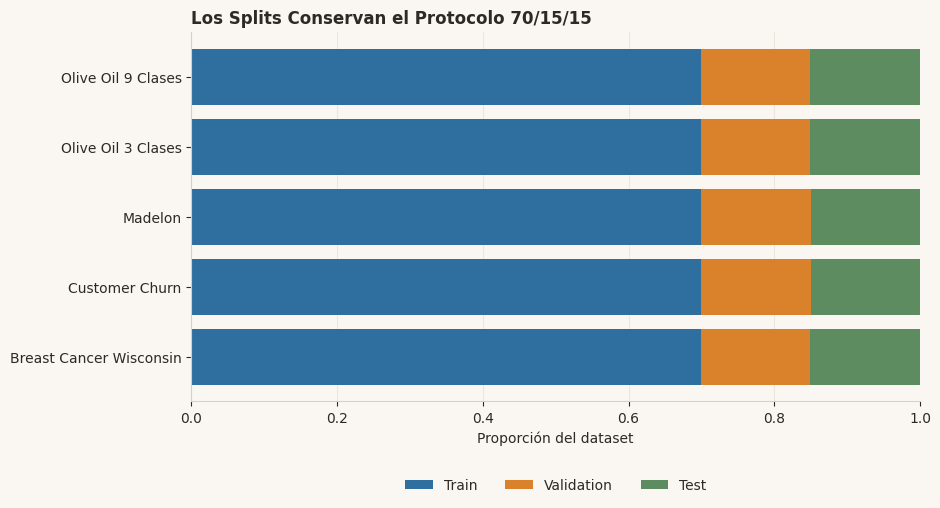

In [30]:
figura, eje = plt.subplots(figsize=(9.4, 4.8))
pivot_tamanos = tamanos_split.pivot(index="dataset", columns="split", values="proporcion").loc[DATASET_ORDER, SPLIT_ORDER]
left_values = np.zeros(len(pivot_tamanos))
for split_name in SPLIT_ORDER:
    eje.barh([etiqueta_dataset(name) for name in pivot_tamanos.index], pivot_tamanos[split_name], left=left_values, color=SPLIT_COLORS[split_name], label=split_name.title())
    left_values += pivot_tamanos[split_name].to_numpy()
eje.set_xlim(0, 1)
eje.set_xlabel("Proporción del dataset")
eje.set_title("Los Splits Conservan el Protocolo 70/15/15", loc="left", fontweight="bold")
eje.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.28))
aplicar_estilo_eje(eje, eje_rejilla="x")
guardar_figura(figura, "fase4_tamanos_split.png")
plt.show()


La figura global confirma que las proporciones observadas siguen el protocolo 70/15/15 con desviaciones máximas pequeñas: 0,00114 en `breast_cancer_wisconsin`, 0,0000009 en `customer_churn` y 0,000699 en cada formulación de `olive_oil`; `madelon` queda exactamente en 0,700/0,150/0,150. Esta estabilidad de tamaño abre la comprobación más estricta por dataset: índices conservados, estratificación y ausencia de solapes.


### Tamaños de Split: `breast_cancer_wisconsin`


In [31]:
tamanos_breast_cancer_wisconsin = tamanos_split[tamanos_split["dataset"].eq("breast_cancer_wisconsin")]
indices_breast_cancer_wisconsin = indices_split[indices_split["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(tamanos_breast_cancer_wisconsin, "Tamaños - Breast Cancer Wisconsin", n=10)
mostrar_tabla(indices_breast_cancer_wisconsin.groupby("split", as_index=False).agg(indice_min=("original_index", "min"), indice_max=("original_index", "max"), n=("original_index", "count")), "Rango de índices conservados - Breast Cancer Wisconsin", n=10)


**Tamaños - Breast Cancer Wisconsin** - 3 filas, 6 columnas.

,Dataset,Partición,Filas,Proporción,proporcion_esperada,delta_abs
0,breast_cancer_wisconsin,train,398,0.699473,0.70,0.000527
1,breast_cancer_wisconsin,validation,85,0.149385,0.15,0.000615
2,breast_cancer_wisconsin,test,86,0.151142,0.15,0.001142


**Rango de índices conservados - Breast Cancer Wisconsin** - 3 filas, 4 columnas.

,Partición,Índice mínimo,Índice máximo,N
0,test,4,539,86
1,train,0,568,398
2,validation,6,563,85


El reparto queda en 398 filas train, 85 validation y 86 test. La mayor desviación frente al 70/15/15 es 0,00114, causada solo por redondeo entero.


### Tamaños de Split: `customer_churn`


In [32]:
tamanos_customer_churn = tamanos_split[tamanos_split["dataset"].eq("customer_churn")]
indices_customer_churn = indices_split[indices_split["dataset"].eq("customer_churn")]

mostrar_tabla(tamanos_customer_churn, "Tamaños - Customer Churn", n=10)
mostrar_tabla(indices_customer_churn.groupby("split", as_index=False).agg(indice_min=("original_index", "min"), indice_max=("original_index", "max"), n=("original_index", "count")), "Rango de índices conservados - Customer Churn", n=10)


**Tamaños - Customer Churn** - 3 filas, 6 columnas.

,Dataset,Partición,Filas,Proporción,proporcion_esperada,delta_abs
3,customer_churn,train,308582,0.699999,0.70,9.073751e-07
4,customer_churn,validation,66125,0.150000,0.15,4.536876e-07
5,customer_churn,test,66125,0.150000,0.15,4.536876e-07


**Rango de índices conservados - Customer Churn** - 3 filas, 4 columnas.

,Partición,Índice mínimo,Índice máximo,N
0,test,2,440831,66125
1,train,0,440830,308582
2,validation,4,440817,66125


El reparto queda en 308.582 filas train y 66.125 en cada partición de validación y test. La desviación máxima frente al protocolo es menor que 0,000001.


### Tamaños de Split: `madelon`


In [33]:
tamanos_madelon = tamanos_split[tamanos_split["dataset"].eq("madelon")]
indices_madelon = indices_split[indices_split["dataset"].eq("madelon")]

mostrar_tabla(tamanos_madelon, "Tamaños - Madelon", n=10)
mostrar_tabla(indices_madelon.groupby("split", as_index=False).agg(indice_min=("original_index", "min"), indice_max=("original_index", "max"), n=("original_index", "count")), "Rango de índices conservados - Madelon", n=10)


**Tamaños - Madelon** - 3 filas, 6 columnas.

,Dataset,Partición,Filas,Proporción,proporcion_esperada,delta_abs
6,madelon,train,1400,0.70,0.70,0.0
7,madelon,validation,300,0.15,0.15,0.0
8,madelon,test,300,0.15,0.15,0.0


**Rango de índices conservados - Madelon** - 3 filas, 4 columnas.

,Partición,Índice mínimo,Índice máximo,N
0,test,5,1999,300
1,train,0,1998,1400
2,validation,6,1992,300


El split produce 1.400 filas train, 300 validation y 300 test. Las proporciones son exactamente 0,700, 0,150 y 0,150.


### Tamaños de Split: `olive_oil_3class`


In [34]:
tamanos_olive_oil_3class = tamanos_split[tamanos_split["dataset"].eq("olive_oil_3class")]
indices_olive_oil_3class = indices_split[indices_split["dataset"].eq("olive_oil_3class")]

mostrar_tabla(tamanos_olive_oil_3class, "Tamaños - Olive Oil 3 Clases", n=10)
mostrar_tabla(indices_olive_oil_3class.groupby("split", as_index=False).agg(indice_min=("original_index", "min"), indice_max=("original_index", "max"), n=("original_index", "count")), "Rango de índices conservados - Olive Oil 3 Clases", n=10)


**Tamaños - Olive Oil 3 Clases** - 3 filas, 6 columnas.

,Dataset,Partición,Filas,Proporción,proporcion_esperada,delta_abs
9,olive_oil_3class,train,400,0.699301,0.70,0.000699
10,olive_oil_3class,validation,86,0.150350,0.15,0.000350
11,olive_oil_3class,test,86,0.150350,0.15,0.000350


**Rango de índices conservados - Olive Oil 3 Clases** - 3 filas, 4 columnas.

,Partición,Índice mínimo,Índice máximo,N
0,test,0,571,86
1,train,1,568,400
2,validation,2,558,86


El reparto queda en 400 filas train, 86 validation y 86 test. La estratificación es necesaria porque las 3 macro-regiones no tienen el mismo tamaño.


### Tamaños de Split: `olive_oil_9class`


In [35]:
tamanos_olive_oil_9class = tamanos_split[tamanos_split["dataset"].eq("olive_oil_9class")]
indices_olive_oil_9class = indices_split[indices_split["dataset"].eq("olive_oil_9class")]

mostrar_tabla(tamanos_olive_oil_9class, "Tamaños - Olive Oil 9 Clases", n=10)
mostrar_tabla(indices_olive_oil_9class.groupby("split", as_index=False).agg(indice_min=("original_index", "min"), indice_max=("original_index", "max"), n=("original_index", "count")), "Rango de índices conservados - Olive Oil 9 Clases", n=10)


**Tamaños - Olive Oil 9 Clases** - 3 filas, 6 columnas.

,Dataset,Partición,Filas,Proporción,proporcion_esperada,delta_abs
12,olive_oil_9class,train,400,0.699301,0.70,0.000699
13,olive_oil_9class,validation,86,0.150350,0.15,0.000350
14,olive_oil_9class,test,86,0.150350,0.15,0.000350


**Rango de índices conservados - Olive Oil 9 Clases** - 3 filas, 4 columnas.

,Partición,Índice mínimo,Índice máximo,N
0,test,0,569,86
1,train,1,571,400
2,validation,4,570,86


El reparto también queda en 400/86/86. La auditoría del target comprueba después que las 9 clases regionales sigan presentes en las tres particiones.


## 4.4 Recarga, Duplicados y Solapes Entre Particiones

Se recargan las particiones guardadas y se comprueba que `X` e `y` mantienen longitud, columnas e índices. Después se auditan solapes de índices y de filas idénticas entre splits.


In [36]:
def recargar_split(nombre_dataset, split_name):
    dataset_dir = SPLITS_DIR / nombre_dataset
    x_split = pd.read_csv(dataset_dir / f"X_{split_name}.csv", index_col="original_index")
    y_split = pd.read_csv(dataset_dir / f"y_{split_name}.csv", index_col="original_index")["target"]
    return x_split, y_split


def comprobar_recarga_split(nombre_dataset, split_name):
    x_guardado, y_guardado = splits_dataset[nombre_dataset][split_name]
    x_recargado, y_recargado = recargar_split(nombre_dataset, split_name)
    return {
        "dataset": nombre_dataset,
        "split": split_name,
        "filas_X": len(x_recargado),
        "filas_y": len(y_recargado),
        "columnas_X": x_recargado.shape[1],
        "len_X_eq_y": len(x_recargado) == len(y_recargado),
        "columnas_ok": list(x_recargado.columns) == list(x_guardado.columns),
        "indice_ok": list(x_recargado.index) == list(x_guardado.index),
    }


In [37]:
def hash_filas(datos_split):
    return pd.util.hash_pandas_object(datos_split, index=False)


def medir_solape_splits(nombre_dataset, split_a, split_b):
    x_a = splits_dataset[nombre_dataset][split_a][0]
    x_b = splits_dataset[nombre_dataset][split_b][0]
    return {
        "dataset": nombre_dataset,
        "split_a": split_a,
        "split_b": split_b,
        "index_overlap": len(set(x_a.index) & set(x_b.index)),
        "row_hash_overlap": len(set(hash_filas(x_a)) & set(hash_filas(x_b))),
    }


In [38]:
def contar_duplicados_internos(nombre_dataset, split_name):
    x_split = splits_dataset[nombre_dataset][split_name][0]
    return {
        "dataset": nombre_dataset,
        "split": split_name,
        "duplicados_X": int(x_split.duplicated().sum()),
    }


def combinaciones_split():
    return [("train", "validation"), ("train", "test"), ("validation", "test")]


In [39]:
recarga_splits = pd.DataFrame([
    comprobar_recarga_split(nombre_dataset, split_name)
    for nombre_dataset in DATASET_ORDER
    for split_name in SPLIT_ORDER
])

solapes_split = pd.DataFrame([
    medir_solape_splits(nombre_dataset, split_a, split_b)
    for nombre_dataset in DATASET_ORDER
    for split_a, split_b in combinaciones_split()
])

duplicados_internos = pd.DataFrame([
    contar_duplicados_internos(nombre_dataset, split_name)
    for nombre_dataset in DATASET_ORDER
    for split_name in SPLIT_ORDER
])

guardar_tabla(recarga_splits, "fase4_recarga_splits.csv")
guardar_tabla(solapes_split, "fase4_solapes_splits.csv")
guardar_tabla(duplicados_internos, "fase4_duplicados_internos.csv")
mostrar_tabla(recarga_splits, "Comprobación de recarga", n=15)
mostrar_tabla(solapes_split, "Solapes entre splits", n=15)
mostrar_tabla(duplicados_internos, "Duplicados internos por split", n=15)


**Comprobación de recarga** - 15 filas, 8 columnas.

,Dataset,Partición,filas_X,filas_y,columnas_X,len_X_eq_y,columnas_ok,indice_ok
0,breast_cancer_wisconsin,train,398,398,30,True,True,True
1,breast_cancer_wisconsin,validation,85,85,30,True,True,True
2,breast_cancer_wisconsin,test,86,86,30,True,True,True
3,customer_churn,train,308582,308582,10,True,True,True
4,customer_churn,validation,66125,66125,10,True,True,True
5,customer_churn,test,66125,66125,10,True,True,True
6,madelon,train,1400,1400,500,True,True,True
7,madelon,validation,300,300,500,True,True,True
8,madelon,test,300,300,500,True,True,True
9,olive_oil_3class,train,400,400,8,True,True,True


**Solapes entre splits** - 15 filas, 5 columnas.

,Dataset,split_a,split_b,Solape de índice,Solape de filas
0,breast_cancer_wisconsin,train,validation,0,0
1,breast_cancer_wisconsin,train,test,0,0
2,breast_cancer_wisconsin,validation,test,0,0
3,customer_churn,train,validation,0,0
4,customer_churn,train,test,0,0
5,customer_churn,validation,test,0,0
6,madelon,train,validation,0,0
7,madelon,train,test,0,0
8,madelon,validation,test,0,0
9,olive_oil_3class,train,validation,0,0


**Duplicados internos por split** - 15 filas, 3 columnas.

,Dataset,Partición,Duplicados en X
0,breast_cancer_wisconsin,train,0
1,breast_cancer_wisconsin,validation,0
2,breast_cancer_wisconsin,test,0
3,customer_churn,train,0
4,customer_churn,validation,0
5,customer_churn,test,0
6,madelon,train,0
7,madelon,validation,0
8,madelon,test,0
9,olive_oil_3class,train,0


La recarga global valida 15 pares `X/y` con igualdad de filas, columnas e índices en todas las particiones. Los 15 pares de splits tienen `index_overlap=0` y `row_hash_overlap=0`, y los 15 splits presentan `duplicados_X=0`; por tanto, las salidas guardadas reproducen exactamente la asignación creada en memoria antes de auditar distribuciones.


### Integridad de Splits: `breast_cancer_wisconsin`


In [40]:
recarga_breast_cancer_wisconsin = recarga_splits[recarga_splits["dataset"].eq("breast_cancer_wisconsin")]
solapes_breast_cancer_wisconsin = solapes_split[solapes_split["dataset"].eq("breast_cancer_wisconsin")]
duplicados_breast_cancer_wisconsin = duplicados_internos[duplicados_internos["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(recarga_breast_cancer_wisconsin, "Recarga - Breast Cancer Wisconsin", n=10)
mostrar_tabla(solapes_breast_cancer_wisconsin, "Solapes - Breast Cancer Wisconsin", n=10)
mostrar_tabla(duplicados_breast_cancer_wisconsin, "Duplicados internos - Breast Cancer Wisconsin", n=10)


**Recarga - Breast Cancer Wisconsin** - 3 filas, 8 columnas.

,Dataset,Partición,filas_X,filas_y,columnas_X,len_X_eq_y,columnas_ok,indice_ok
0,breast_cancer_wisconsin,train,398,398,30,True,True,True
1,breast_cancer_wisconsin,validation,85,85,30,True,True,True
2,breast_cancer_wisconsin,test,86,86,30,True,True,True


**Solapes - Breast Cancer Wisconsin** - 3 filas, 5 columnas.

,Dataset,split_a,split_b,Solape de índice,Solape de filas
0,breast_cancer_wisconsin,train,validation,0,0
1,breast_cancer_wisconsin,train,test,0,0
2,breast_cancer_wisconsin,validation,test,0,0


**Duplicados internos - Breast Cancer Wisconsin** - 3 filas, 3 columnas.

,Dataset,Partición,Duplicados en X
0,breast_cancer_wisconsin,train,0
1,breast_cancer_wisconsin,validation,0
2,breast_cancer_wisconsin,test,0


Los 3 splits recargan con `len_X_eq_y=True`, `columnas_ok=True` e `indice_ok=True`. Los 3 pares de particiones tienen 0 solapes de índice y 0 solapes de hash.


### Integridad de Splits: `customer_churn`


In [41]:
recarga_customer_churn = recarga_splits[recarga_splits["dataset"].eq("customer_churn")]
solapes_customer_churn = solapes_split[solapes_split["dataset"].eq("customer_churn")]
duplicados_customer_churn = duplicados_internos[duplicados_internos["dataset"].eq("customer_churn")]

mostrar_tabla(recarga_customer_churn, "Recarga - Customer Churn", n=10)
mostrar_tabla(solapes_customer_churn, "Solapes - Customer Churn", n=10)
mostrar_tabla(duplicados_customer_churn, "Duplicados internos - Customer Churn", n=10)


**Recarga - Customer Churn** - 3 filas, 8 columnas.

,Dataset,Partición,filas_X,filas_y,columnas_X,len_X_eq_y,columnas_ok,indice_ok
3,customer_churn,train,308582,308582,10,True,True,True
4,customer_churn,validation,66125,66125,10,True,True,True
5,customer_churn,test,66125,66125,10,True,True,True


**Solapes - Customer Churn** - 3 filas, 5 columnas.

,Dataset,split_a,split_b,Solape de índice,Solape de filas
3,customer_churn,train,validation,0,0
4,customer_churn,train,test,0,0
5,customer_churn,validation,test,0,0


**Duplicados internos - Customer Churn** - 3 filas, 3 columnas.

,Dataset,Partición,Duplicados en X
3,customer_churn,train,0
4,customer_churn,validation,0
5,customer_churn,test,0


La comprobación cubre 440.832 índices repartidos en 3 pares `X/y`. Incluso con 308.582 filas en train, los solapes de índice y de hash quedan en 0.


### Integridad de Splits: `madelon`


In [42]:
recarga_madelon = recarga_splits[recarga_splits["dataset"].eq("madelon")]
solapes_madelon = solapes_split[solapes_split["dataset"].eq("madelon")]
duplicados_madelon = duplicados_internos[duplicados_internos["dataset"].eq("madelon")]

mostrar_tabla(recarga_madelon, "Recarga - Madelon", n=10)
mostrar_tabla(solapes_madelon, "Solapes - Madelon", n=10)
mostrar_tabla(duplicados_madelon, "Duplicados internos - Madelon", n=10)


**Recarga - Madelon** - 3 filas, 8 columnas.

,Dataset,Partición,filas_X,filas_y,columnas_X,len_X_eq_y,columnas_ok,indice_ok
6,madelon,train,1400,1400,500,True,True,True
7,madelon,validation,300,300,500,True,True,True
8,madelon,test,300,300,500,True,True,True


**Solapes - Madelon** - 3 filas, 5 columnas.

,Dataset,split_a,split_b,Solape de índice,Solape de filas
6,madelon,train,validation,0,0
7,madelon,train,test,0,0
8,madelon,validation,test,0,0


**Duplicados internos - Madelon** - 3 filas, 3 columnas.

,Dataset,Partición,Duplicados en X
6,madelon,train,0
7,madelon,validation,0
8,madelon,test,0


Los 3 splits conservan 500 columnas tras recarga. Los pares train-validation, train-test y validation-test tienen `index_overlap=0`.


### Integridad de Splits: `olive_oil_3class`


In [43]:
recarga_olive_oil_3class = recarga_splits[recarga_splits["dataset"].eq("olive_oil_3class")]
solapes_olive_oil_3class = solapes_split[solapes_split["dataset"].eq("olive_oil_3class")]
duplicados_olive_oil_3class = duplicados_internos[duplicados_internos["dataset"].eq("olive_oil_3class")]

mostrar_tabla(recarga_olive_oil_3class, "Recarga - Olive Oil 3 Clases", n=10)
mostrar_tabla(solapes_olive_oil_3class, "Solapes - Olive Oil 3 Clases", n=10)
mostrar_tabla(duplicados_olive_oil_3class, "Duplicados internos - Olive Oil 3 Clases", n=10)


**Recarga - Olive Oil 3 Clases** - 3 filas, 8 columnas.

,Dataset,Partición,filas_X,filas_y,columnas_X,len_X_eq_y,columnas_ok,indice_ok
9,olive_oil_3class,train,400,400,8,True,True,True
10,olive_oil_3class,validation,86,86,8,True,True,True
11,olive_oil_3class,test,86,86,8,True,True,True


**Solapes - Olive Oil 3 Clases** - 3 filas, 5 columnas.

,Dataset,split_a,split_b,Solape de índice,Solape de filas
9,olive_oil_3class,train,validation,0,0
10,olive_oil_3class,train,test,0,0
11,olive_oil_3class,validation,test,0,0


**Duplicados internos - Olive Oil 3 Clases** - 3 filas, 3 columnas.

,Dataset,Partición,Duplicados en X
9,olive_oil_3class,train,0
10,olive_oil_3class,validation,0
11,olive_oil_3class,test,0


Los 400, 86 y 86 registros recargan con 8 columnas predictoras y sin duplicados internos. En un dataset pequeño, este 0 de solapes es una condición crítica.


### Integridad de Splits: `olive_oil_9class`


In [44]:
recarga_olive_oil_9class = recarga_splits[recarga_splits["dataset"].eq("olive_oil_9class")]
solapes_olive_oil_9class = solapes_split[solapes_split["dataset"].eq("olive_oil_9class")]
duplicados_olive_oil_9class = duplicados_internos[duplicados_internos["dataset"].eq("olive_oil_9class")]

mostrar_tabla(recarga_olive_oil_9class, "Recarga - Olive Oil 9 Clases", n=10)
mostrar_tabla(solapes_olive_oil_9class, "Solapes - Olive Oil 9 Clases", n=10)
mostrar_tabla(duplicados_olive_oil_9class, "Duplicados internos - Olive Oil 9 Clases", n=10)


**Recarga - Olive Oil 9 Clases** - 3 filas, 8 columnas.

,Dataset,Partición,filas_X,filas_y,columnas_X,len_X_eq_y,columnas_ok,indice_ok
12,olive_oil_9class,train,400,400,8,True,True,True
13,olive_oil_9class,validation,86,86,8,True,True,True
14,olive_oil_9class,test,86,86,8,True,True,True


**Solapes - Olive Oil 9 Clases** - 3 filas, 5 columnas.

,Dataset,split_a,split_b,Solape de índice,Solape de filas
12,olive_oil_9class,train,validation,0,0
13,olive_oil_9class,train,test,0,0
14,olive_oil_9class,validation,test,0,0


**Duplicados internos - Olive Oil 9 Clases** - 3 filas, 3 columnas.

,Dataset,Partición,Duplicados en X
12,olive_oil_9class,train,0
13,olive_oil_9class,validation,0
14,olive_oil_9class,test,0


La formulación multiclase comparte origen con `olive_oil_3class`, pero dentro de sus 3 particiones hay 0 solapes de índice y 0 filas duplicadas.


## 4.5 Conservación del Target Entre Splits

Se comparan las proporciones de clase entre `train`, `validation` y `test` para comprobar que ninguna partición cambia el problema de clasificación. Como los splits se construyen con estratificación cuando las clases lo permiten, el contraste chi-cuadrado no se interpreta como una prueba de hipótesis informativa e independiente: funciona como control de coherencia del estratificado y como alarma si una clase desaparece o queda con frecuencia esperada demasiado baja. Su `p_value` se lee junto con el tamaño muestral, porque en datasets grandes puede detectar diferencias muy pequeñas.

La lectura combina tres evidencias: proporciones por clase, mayor delta frente a train y recuento esperado mínimo del chi-cuadrado. Una clase ausente o un delta grande sería más preocupante que un p-valor aislado. Esta sección no decide modelos; solo verifica que la selección posterior trabajará sobre el mismo problema de clasificación en train, validation y test.

La columna `max_delta_proporcion` mide, para cada clase, la diferencia entre la mayor y la menor proporción observada entre splits. Es una medida práctica del tamaño del cambio. `min_expected_count` muestra la celda esperada más pequeña del contraste chi-cuadrado; si es baja, la aproximación del test es menos estable. `clases_ausentes` cuenta celdas con frecuencia cero en la tabla split-clase; una clase ausente en `validation` o `test` sería una limitación directa para evaluar modelos sobre esa clase.


In [45]:
def crear_distribucion_target(nombre_dataset):
    rows = []
    clases_dataset = clases_target_dataset(nombre_dataset)
    for split_name, (_, y_split) in splits_dataset[nombre_dataset].items():
        rows.extend(crear_filas_target_split(nombre_dataset, split_name, y_split, clases_dataset))
    return pd.DataFrame(rows)


def clases_target_dataset(nombre_dataset):
    clases = set()
    for _, y_split in splits_dataset[nombre_dataset].values():
        clases.update(y_split.dropna().unique())
    return sorted(clases, key=lambda value: str(value))


def crear_filas_target_split(nombre_dataset, split_name, y_split, clases_dataset):
    counts = y_split.value_counts(dropna=False).reindex(clases_dataset, fill_value=0)
    return [
        {"dataset": nombre_dataset, "split": split_name, "clase": class_value, "n": int(count), "proporcion": count / len(y_split)}
        for class_value, count in counts.items()
    ]


In [46]:
def calcular_diferencias_target(nombre_dataset):
    distribution = distribucion_target[distribucion_target["dataset"].eq(nombre_dataset)]
    rows = []
    for class_value, group in distribution.groupby("clase"):
        rows.append(crear_fila_diferencia_target(nombre_dataset, class_value, group))
    return pd.DataFrame(rows)


def crear_fila_diferencia_target(nombre_dataset, class_value, group):
    return {
        "dataset": nombre_dataset,
        "clase": class_value,
        "min_proporcion": group["proporcion"].min(),
        "max_proporcion": group["proporcion"].max(),
        "max_delta_proporcion": group["proporcion"].max() - group["proporcion"].min(),
    }


In [47]:
def crear_tabla_contingencia_target(nombre_dataset):
    rows = []
    for split_name, (_, y_split) in splits_dataset[nombre_dataset].items():
        rows.extend({"split": split_name, "clase": class_value} for class_value in y_split)
    return pd.crosstab(pd.DataFrame(rows)["split"], pd.DataFrame(rows)["clase"])


def probar_homogeneidad_target(nombre_dataset):
    contingency = crear_tabla_contingencia_target(nombre_dataset)
    statistic, p_value, _, expected = chi2_contingency(contingency)
    return {
        "dataset": nombre_dataset,
        "chi2_statistic": float(statistic),
        "chi2_p_value": float(p_value),
        "min_expected_count": float(expected.min()),
        "clases_ausentes": int((contingency == 0).sum().sum()),
    }


In [48]:
def resumen_target_plot(nombre_dataset):
    test_row = tests_target[tests_target["dataset"].eq(nombre_dataset)].iloc[0]
    max_delta = diferencias_target[diferencias_target["dataset"].eq(nombre_dataset)]["max_delta_proporcion"].max()
    return {
        "max_delta": max_delta,
        "min_expected": test_row["min_expected_count"],
        "clases_ausentes": int(test_row["clases_ausentes"]),
    }


def graficar_target_dataset(nombre_dataset):
    subset = distribucion_target[distribucion_target["dataset"].eq(nombre_dataset)]
    pivot = subset.pivot(index="clase", columns="split", values="proporcion").fillna(0)
    delta_train = pivot[SPLIT_ORDER].subtract(pivot["train"], axis=0).abs()[["validation", "test"]].max(axis=1)
    top_delta = delta_train.sort_values(ascending=False).head(12).sort_values()
    metricas = resumen_target_plot(nombre_dataset)
    figura, ejes = plt.subplots(1, 2, figsize=(12.0, 4.8), gridspec_kw={"width_ratios": [1.45, 1]})
    pivot[SPLIT_ORDER].plot(kind="bar", ax=ejes[0], color=[SPLIT_COLORS[name] for name in SPLIT_ORDER], width=0.78)
    ejes[0].set_ylabel("Proporción")
    ejes[0].set_xlabel("Clase")
    ejes[0].set_title("Proporciones por clase", loc="left", fontweight="bold")
    ejes[0].legend(frameon=False, ncol=3, title="")
    ejes[1].barh(top_delta.index.astype(str), top_delta.values, color="#7A8F5A")
    ejes[1].set_xlabel("Mayor delta frente a train")
    ejes[1].set_title("Clases más sensibles", loc="left", fontweight="bold")
    ejes[1].text(
        0.98,
        0.05,
        f"max delta={metricas['max_delta']:.3f}\nmin esperado={metricas['min_expected']:.1f}\nclases ausentes={metricas['clases_ausentes']}",
        transform=ejes[1].transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox={"facecolor": "#FAF7F2", "edgecolor": "#D8D0C4", "boxstyle": "round,pad=0.35"},
    )
    for eje in ejes:
        aplicar_estilo_eje(eje, eje_rejilla="y" if eje is ejes[0] else "x")
    figura.suptitle(f"{etiqueta_dataset(nombre_dataset)}: Representatividad del Target", fontsize=13, y=1.03)
    figura.tight_layout()
    guardar_figura(figura, f"fase4_target_{nombre_dataset}.png")
    plt.show()


In [49]:
distribucion_target = pd.concat([crear_distribucion_target(nombre_dataset) for nombre_dataset in DATASET_ORDER], ignore_index=True)
diferencias_target = pd.concat([calcular_diferencias_target(nombre_dataset) for nombre_dataset in DATASET_ORDER], ignore_index=True)
tests_target = pd.DataFrame([probar_homogeneidad_target(nombre_dataset) for nombre_dataset in DATASET_ORDER])

guardar_tabla(distribucion_target, "fase4_target_distribucion.csv")
guardar_tabla(diferencias_target, "fase4_target_diferencias.csv")
guardar_tabla(tests_target, "fase4_target_tests.csv")
mostrar_tabla(tests_target, "Contrastes de homogeneidad del target", n=10)
mostrar_tabla(diferencias_target.sort_values("max_delta_proporcion", ascending=False), "Mayores diferencias de proporción", n=15)


**Contrastes de homogeneidad del target** - 5 filas, 5 columnas.

,Dataset,chi2_statistic,chi2_p_value,min_expected_count,clases_ausentes
0,breast_cancer_wisconsin,6.475442e-03,0.996768,31.669596,0
1,customer_churn,2.354911e-07,1.000000,28625.036579,0
2,madelon,0.000000e+00,1.000000,150.000000,0
3,olive_oil_3class,5.144057e-02,0.999675,14.734266,0
4,olive_oil_9class,5.669704e-01,1.000000,3.758741,0


**Mayores diferencias de proporción** - 18 filas, 5 columnas.

,Dataset,Clase,min_proporcion,max_proporcion,Delta máximo de proporción
6,olive_oil_3class,1,0.558140,0.569767,1.162791e-02
9,olive_oil_9class,0,0.093023,0.104651,1.162791e-02
14,olive_oil_9class,5,0.058140,0.069767,1.162791e-02
13,olive_oil_9class,4,0.034884,0.046512,1.162791e-02
11,olive_oil_9class,2,0.081395,0.093023,1.162791e-02
16,olive_oil_9class,7,0.081395,0.093023,1.162791e-02
17,olive_oil_9class,8,0.081395,0.093023,1.162791e-02
8,olive_oil_3class,3,0.255814,0.267442,1.162791e-02
0,breast_cancer_wisconsin,0,0.623529,0.628141,4.611292e-03
1,breast_cancer_wisconsin,1,0.371859,0.376471,4.611292e-03


La lectura global del target no muestra pérdidas de clase: `clases_ausentes=0` en los 5 datasets. El mayor delta de proporción es 0,0116 y aparece en varias clases de `olive_oil`, mientras que `madelon` queda en 0,0000 y `customer_churn` en 0,00000079; los p-valores chi-cuadrado permanecen entre 0,9968 y 1,0000, con mínimo esperado de 3,76 en `olive_oil_9class`, que será la formulación más sensible por tamaño de clase.


### Target Entre Splits: `breast_cancer_wisconsin`


**Distribución target - Breast Cancer Wisconsin** - 6 filas, 5 columnas.

,Dataset,Partición,Clase,N,Proporción
0,breast_cancer_wisconsin,train,0,250,0.628141
1,breast_cancer_wisconsin,train,1,148,0.371859
2,breast_cancer_wisconsin,validation,0,53,0.623529
3,breast_cancer_wisconsin,validation,1,32,0.376471
4,breast_cancer_wisconsin,test,0,54,0.627907
5,breast_cancer_wisconsin,test,1,32,0.372093


**Diferencias target - Breast Cancer Wisconsin** - 2 filas, 5 columnas.

,Dataset,Clase,min_proporcion,max_proporcion,Delta máximo de proporción
0,breast_cancer_wisconsin,0,0.623529,0.628141,0.004611
1,breast_cancer_wisconsin,1,0.371859,0.376471,0.004611


**Test target - Breast Cancer Wisconsin** - 1 filas, 5 columnas.

,Dataset,chi2_statistic,chi2_p_value,min_expected_count,clases_ausentes
0,breast_cancer_wisconsin,0.006475,0.996768,31.669596,0


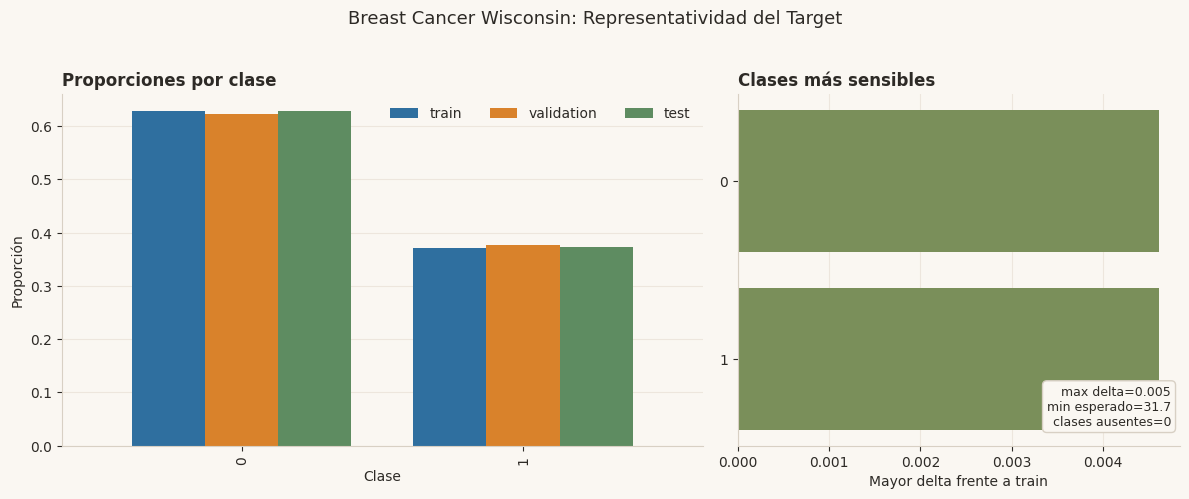

In [50]:
target_distribucion_breast_cancer_wisconsin = distribucion_target[distribucion_target["dataset"].eq("breast_cancer_wisconsin")]
target_diferencias_breast_cancer_wisconsin = diferencias_target[diferencias_target["dataset"].eq("breast_cancer_wisconsin")]
target_tests_breast_cancer_wisconsin = tests_target[tests_target["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(target_distribucion_breast_cancer_wisconsin, "Distribución target - Breast Cancer Wisconsin", n=30)
mostrar_tabla(target_diferencias_breast_cancer_wisconsin.sort_values("max_delta_proporcion", ascending=False), "Diferencias target - Breast Cancer Wisconsin", n=12)
mostrar_tabla(target_tests_breast_cancer_wisconsin, "Test target - Breast Cancer Wisconsin", n=5)
graficar_target_dataset("breast_cancer_wisconsin")


El máximo delta de proporción es 0.0046 y no hay clases ausentes; el split conserva el desbalance binario original sin cambiar el problema.


### Target Entre Splits: `customer_churn`


**Distribución target - Customer Churn** - 6 filas, 5 columnas.

,Dataset,Partición,Clase,N,Proporción
6,customer_churn,train,0,133583,0.432893
7,customer_churn,train,1,174999,0.567107
8,customer_churn,validation,0,28625,0.432892
9,customer_churn,validation,1,37500,0.567108
10,customer_churn,test,0,28625,0.432892
11,customer_churn,test,1,37500,0.567108


**Diferencias target - Customer Churn** - 2 filas, 5 columnas.

,Dataset,Clase,min_proporcion,max_proporcion,Delta máximo de proporción
3,customer_churn,1,0.567107,0.567108,7.902481e-07
2,customer_churn,0,0.432892,0.432893,7.902481e-07


**Test target - Customer Churn** - 1 filas, 5 columnas.

,Dataset,chi2_statistic,chi2_p_value,min_expected_count,clases_ausentes
1,customer_churn,2.354911e-07,1.0,28625.036579,0


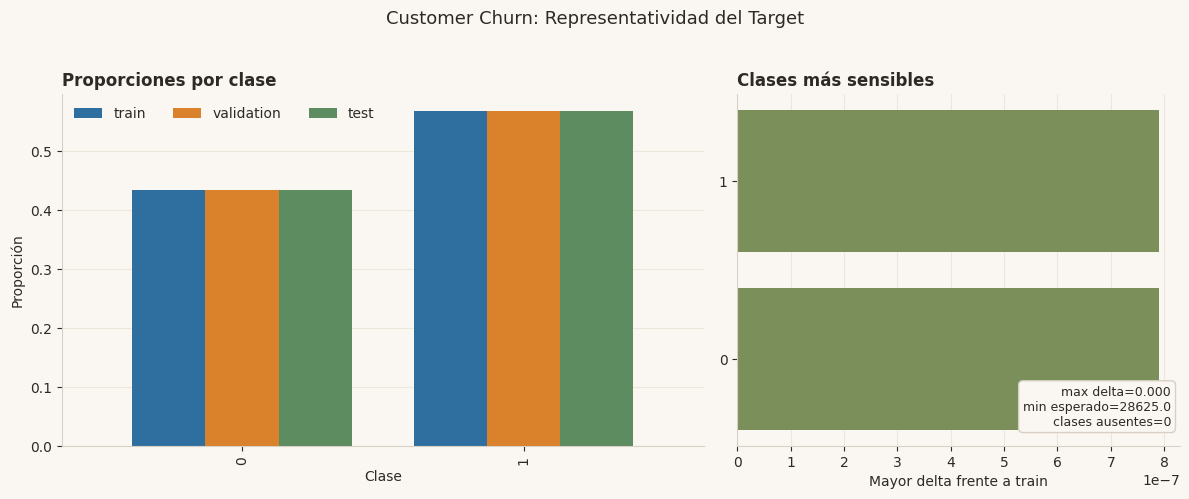

In [51]:
target_distribucion_customer_churn = distribucion_target[distribucion_target["dataset"].eq("customer_churn")]
target_diferencias_customer_churn = diferencias_target[diferencias_target["dataset"].eq("customer_churn")]
target_tests_customer_churn = tests_target[tests_target["dataset"].eq("customer_churn")]

mostrar_tabla(target_distribucion_customer_churn, "Distribución target - Customer Churn", n=30)
mostrar_tabla(target_diferencias_customer_churn.sort_values("max_delta_proporcion", ascending=False), "Diferencias target - Customer Churn", n=12)
mostrar_tabla(target_tests_customer_churn, "Test target - Customer Churn", n=5)
graficar_target_dataset("customer_churn")


El máximo delta es menor que 1e-6. Con 440.832 filas, la conclusión práctica es conservación completa del target, no solo p-valor alto.


### Target Entre Splits: `madelon`


**Distribución target - Madelon** - 6 filas, 5 columnas.

,Dataset,Partición,Clase,N,Proporción
12,madelon,train,0,700,0.5
13,madelon,train,1,700,0.5
14,madelon,validation,0,150,0.5
15,madelon,validation,1,150,0.5
16,madelon,test,0,150,0.5
17,madelon,test,1,150,0.5


**Diferencias target - Madelon** - 2 filas, 5 columnas.

,Dataset,Clase,min_proporcion,max_proporcion,Delta máximo de proporción
4,madelon,0,0.5,0.5,0.0
5,madelon,1,0.5,0.5,0.0


**Test target - Madelon** - 1 filas, 5 columnas.

,Dataset,chi2_statistic,chi2_p_value,min_expected_count,clases_ausentes
2,madelon,0.0,1.0,150.0,0


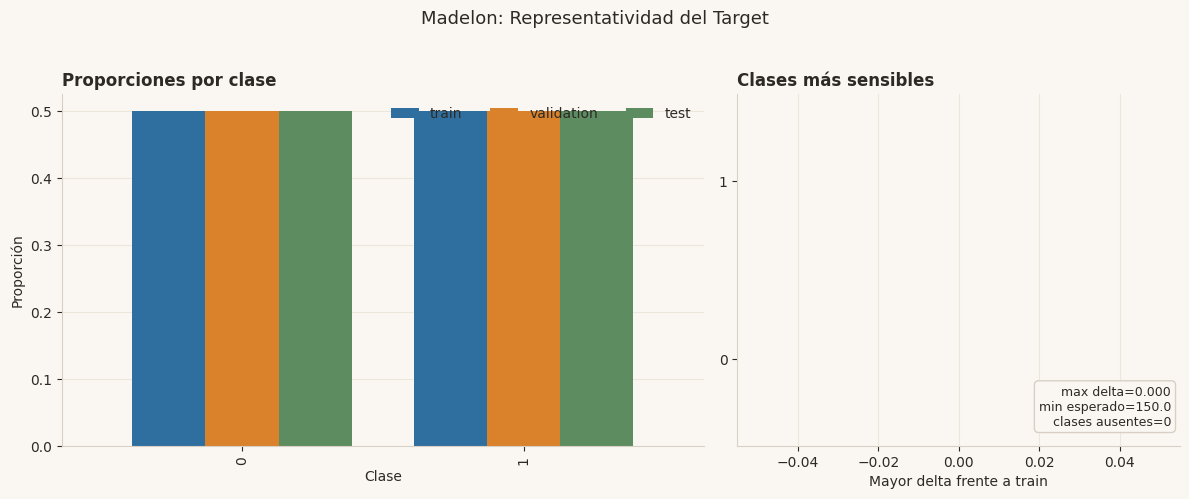

In [52]:
target_distribucion_madelon = distribucion_target[distribucion_target["dataset"].eq("madelon")]
target_diferencias_madelon = diferencias_target[diferencias_target["dataset"].eq("madelon")]
target_tests_madelon = tests_target[tests_target["dataset"].eq("madelon")]

mostrar_tabla(target_distribucion_madelon, "Distribución target - Madelon", n=30)
mostrar_tabla(target_diferencias_madelon.sort_values("max_delta_proporcion", ascending=False), "Diferencias target - Madelon", n=12)
mostrar_tabla(target_tests_madelon, "Test target - Madelon", n=5)
graficar_target_dataset("madelon")


La estratificación deja exactamente 50/50 en las tres particiones. La dificultad posterior no procede del target, sino de la relación 500 features / 2.000 filas.


### Target Entre Splits: `olive_oil_3class`


**Distribución target - Olive Oil 3 Clases** - 9 filas, 5 columnas.

,Dataset,Partición,Clase,N,Proporción
18,olive_oil_3class,train,1,226,0.565000
19,olive_oil_3class,train,2,68,0.170000
20,olive_oil_3class,train,3,106,0.265000
21,olive_oil_3class,validation,1,49,0.569767
22,olive_oil_3class,validation,2,15,0.174419
23,olive_oil_3class,validation,3,22,0.255814
24,olive_oil_3class,test,1,48,0.558140
25,olive_oil_3class,test,2,15,0.174419
26,olive_oil_3class,test,3,23,0.267442


**Diferencias target - Olive Oil 3 Clases** - 3 filas, 5 columnas.

,Dataset,Clase,min_proporcion,max_proporcion,Delta máximo de proporción
6,olive_oil_3class,1,0.558140,0.569767,0.011628
8,olive_oil_3class,3,0.255814,0.267442,0.011628
7,olive_oil_3class,2,0.170000,0.174419,0.004419


**Test target - Olive Oil 3 Clases** - 1 filas, 5 columnas.

,Dataset,chi2_statistic,chi2_p_value,min_expected_count,clases_ausentes
3,olive_oil_3class,0.051441,0.999675,14.734266,0


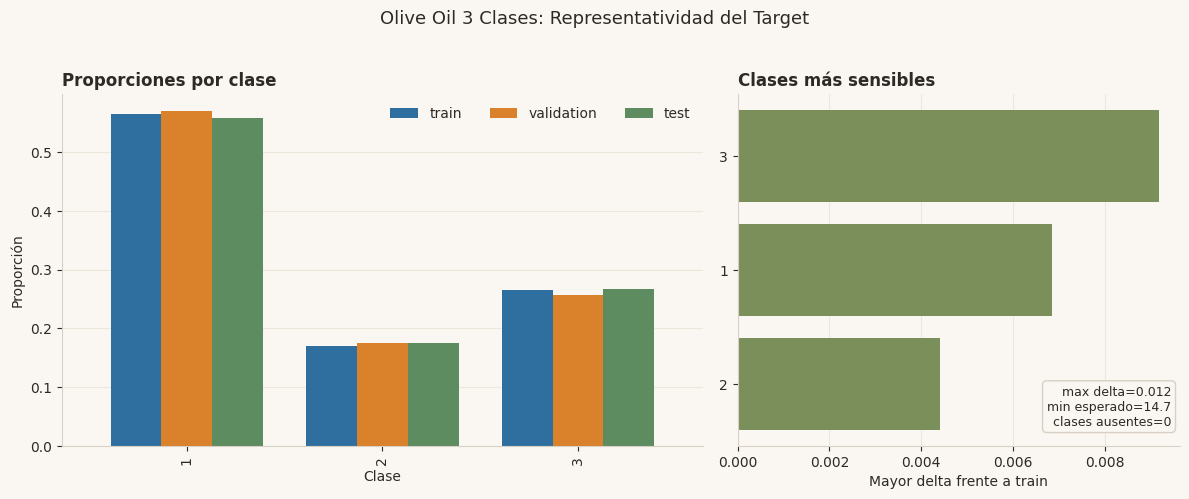

In [53]:
target_distribucion_olive_oil_3class = distribucion_target[distribucion_target["dataset"].eq("olive_oil_3class")]
target_diferencias_olive_oil_3class = diferencias_target[diferencias_target["dataset"].eq("olive_oil_3class")]
target_tests_olive_oil_3class = tests_target[tests_target["dataset"].eq("olive_oil_3class")]

mostrar_tabla(target_distribucion_olive_oil_3class, "Distribución target - Olive Oil 3 Clases", n=30)
mostrar_tabla(target_diferencias_olive_oil_3class.sort_values("max_delta_proporcion", ascending=False), "Diferencias target - Olive Oil 3 Clases", n=12)
mostrar_tabla(target_tests_olive_oil_3class, "Test target - Olive Oil 3 Clases", n=5)
graficar_target_dataset("olive_oil_3class")


El máximo delta queda en 0.0116 y todas las macro-regiones aparecen en train, validation y test. La formulación de 3 clases es representativa.


### Target Entre Splits: `olive_oil_9class`


**Distribución target - Olive Oil 9 Clases** - 27 filas, 5 columnas.

,Dataset,Partición,Clase,N,Proporción
27,olive_oil_9class,train,0,39,0.097500
28,olive_oil_9class,train,1,23,0.057500
29,olive_oil_9class,train,2,35,0.087500
30,olive_oil_9class,train,3,45,0.112500
31,olive_oil_9class,train,4,18,0.045000
32,olive_oil_9class,train,5,25,0.062500
33,olive_oil_9class,train,6,144,0.360000
34,olive_oil_9class,train,7,36,0.090000
35,olive_oil_9class,train,8,35,0.087500
36,olive_oil_9class,validation,0,9,0.104651


**Diferencias target - Olive Oil 9 Clases** - 9 filas, 5 columnas.

,Dataset,Clase,min_proporcion,max_proporcion,Delta máximo de proporción
9,olive_oil_9class,0,0.093023,0.104651,0.011628
13,olive_oil_9class,4,0.034884,0.046512,0.011628
14,olive_oil_9class,5,0.058140,0.069767,0.011628
16,olive_oil_9class,7,0.081395,0.093023,0.011628
11,olive_oil_9class,2,0.081395,0.093023,0.011628
17,olive_oil_9class,8,0.081395,0.093023,0.011628
12,olive_oil_9class,3,0.112500,0.116279,0.003779
10,olive_oil_9class,1,0.057500,0.058140,0.000640
15,olive_oil_9class,6,0.360000,0.360465,0.000465


**Test target - Olive Oil 9 Clases** - 1 filas, 5 columnas.

,Dataset,chi2_statistic,chi2_p_value,min_expected_count,clases_ausentes
4,olive_oil_9class,0.56697,1.0,3.758741,0


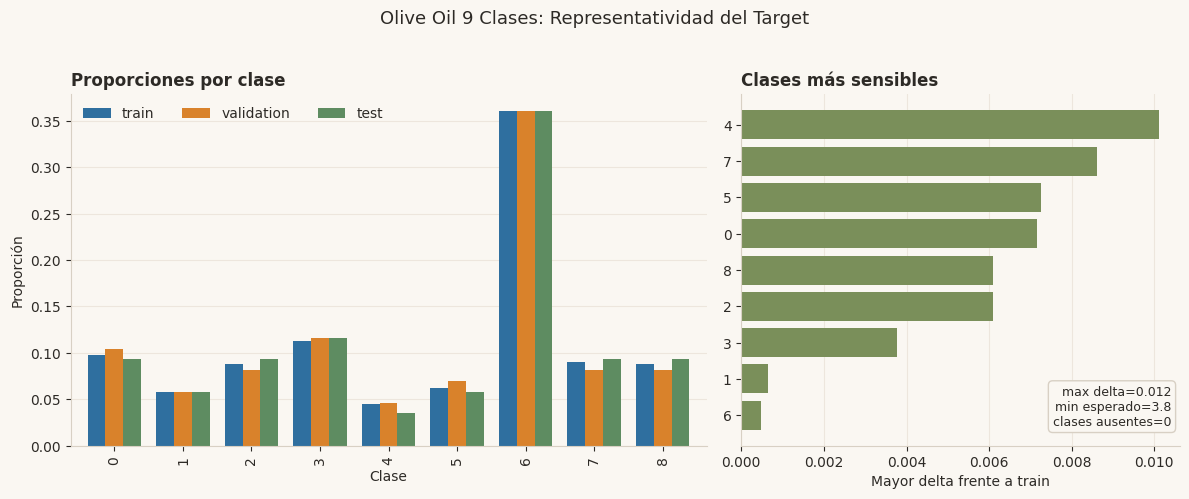

In [54]:
target_distribucion_olive_oil_9class = distribucion_target[distribucion_target["dataset"].eq("olive_oil_9class")]
target_diferencias_olive_oil_9class = diferencias_target[diferencias_target["dataset"].eq("olive_oil_9class")]
target_tests_olive_oil_9class = tests_target[tests_target["dataset"].eq("olive_oil_9class")]

mostrar_tabla(target_distribucion_olive_oil_9class, "Distribución target - Olive Oil 9 Clases", n=30)
mostrar_tabla(target_diferencias_olive_oil_9class.sort_values("max_delta_proporcion", ascending=False), "Diferencias target - Olive Oil 9 Clases", n=12)
mostrar_tabla(target_tests_olive_oil_9class, "Test target - Olive Oil 9 Clases", n=5)
graficar_target_dataset("olive_oil_9class")


Todas las clases están presentes, pero el recuento esperado mínimo es 3.76. El split es válido, aunque la evaluación posterior tendrá intervalos amplios por clases minoritarias.


## 4.6 Drift Univariante de Variables Entre Splits

Se compara `train` frente a `validation` y `test` para detectar cambios de distribución que puedan afectar la evaluación posterior. En variables numéricas, KS mide la mayor distancia entre distribuciones acumuladas y capta cambios de forma o localización; Wasserstein estima cuánto habría que desplazar la masa de una distribución para parecerse a la otra y se estandariza por la desviación típica de `train`; PSI resume cambios por intervalos y facilita una lectura de estabilidad poblacional.

En variables categóricas, el chi-cuadrado contrasta si las frecuencias por categoría cambian entre particiones. La distancia de proporciones resume el tamaño práctico de ese cambio y el PSI categórico conserva la misma lógica de estabilidad que en variables numéricas. Se combinan contrastes y tamaños de efecto porque los p-values dependen del tamaño muestral; aquí el objetivo es localizar señales de revisión, no seleccionar ni descartar variables.

La figura por dataset no dibuja solo el score agregado: separa la métrica que dispara cada alerta. Así se distingue si una variable cambia por forma acumulada (KS), por desplazamiento de escala (Wasserstein/distancia) o por redistribución por intervalos (PSI). Esta distinción importa porque en la selección posterior una alerta de drift es una cautela de representatividad, no una instrucción automática de eliminar variables.


In [55]:
def calcular_psi_categorico(base, comparacion):
    base_prop = base.astype(str).value_counts(normalize=True)
    comp_prop = comparacion.astype(str).value_counts(normalize=True)
    categorias = sorted(set(base_prop.index) | set(comp_prop.index))
    return sumar_psi([base_prop.get(cat, 0) for cat in categorias], [comp_prop.get(cat, 0) for cat in categorias])


def sumar_psi(base_values, comp_values):
    epsilon = 1e-6
    total = 0.0
    for base_value, comp_value in zip(base_values, comp_values):
        base_safe = max(base_value, epsilon)
        comp_safe = max(comp_value, epsilon)
        total += (comp_safe - base_safe) * np.log(comp_safe / base_safe)
    return float(total)


In [56]:
def calcular_psi_numerico(base, comparacion):
    base_clean = pd.to_numeric(base, errors="coerce").dropna()
    comp_clean = pd.to_numeric(comparacion, errors="coerce").dropna()
    if base_clean.nunique() < 2 or comp_clean.empty:
        return np.nan
    cortes = np.unique(np.quantile(base_clean, np.linspace(0, 1, 11)))
    if len(cortes) < 3:
        return np.nan
    base_bins = pd.cut(base_clean, bins=cortes, include_lowest=True)
    comp_bins = pd.cut(comp_clean, bins=cortes, include_lowest=True)
    return calcular_psi_categorico(base_bins, comp_bins)


In [57]:
def calcular_drift_numerico(paquete_drift):
    base_clean = pd.to_numeric(paquete_drift["base"], errors="coerce").dropna()
    comp_clean = pd.to_numeric(paquete_drift["comparacion_serie"], errors="coerce").dropna()
    statistic, p_value = ks_2samp(base_clean, comp_clean)
    std_base = base_clean.std(ddof=0) or 1.0
    wasserstein_std = wasserstein_distance(base_clean, comp_clean) / std_base
    psi_value = calcular_psi_numerico(base_clean, comp_clean)
    metricas = crear_metricas_drift(paquete_drift, {"tipo": "numerica", "statistic": statistic, "p_value": p_value, "distancia": wasserstein_std, "psi": psi_value})
    return crear_fila_drift(metricas)


In [58]:
def calcular_drift_categorico(paquete_drift):
    base = paquete_drift["base"]
    comparacion = paquete_drift["comparacion_serie"]
    contingency = pd.crosstab(pd.Series(["base"] * len(base) + ["comparacion"] * len(comparacion)), pd.concat([base, comparacion]).astype(str))
    statistic, p_value, _, _ = chi2_contingency(contingency)
    distancia = calcular_distancia_proporciones(base, comparacion)
    psi_value = calcular_psi_categorico(base, comparacion)
    metricas = crear_metricas_drift(paquete_drift, {"tipo": "categorica", "statistic": statistic, "p_value": p_value, "distancia": distancia, "psi": psi_value})
    return crear_fila_drift(metricas)


def calcular_distancia_proporciones(base, comparacion):
    base_prop = base.astype(str).value_counts(normalize=True)
    comp_prop = comparacion.astype(str).value_counts(normalize=True)
    categorias = sorted(set(base_prop.index) | set(comp_prop.index))
    return 0.5 * sum(abs(base_prop.get(cat, 0) - comp_prop.get(cat, 0)) for cat in categorias)


In [59]:
def crear_metricas_drift(paquete_drift, medidas_drift):
    return {**paquete_drift, **medidas_drift}


def crear_fila_drift(metricas_drift):
    score = calcular_score_drift(metricas_drift)
    return {
        "dataset": metricas_drift["dataset"],
        "comparacion": metricas_drift["comparacion"],
        "variable": metricas_drift["variable"],
        "tipo": metricas_drift["tipo"],
        "statistic": float(metricas_drift["statistic"]),
        "p_value": float(metricas_drift["p_value"]),
        "distancia": float(metricas_drift["distancia"]),
        "psi": float(metricas_drift["psi"]) if not np.isnan(metricas_drift["psi"]) else np.nan,
        "drift_score": float(score),
        "drift_flag": bool(evaluar_flag_drift(metricas_drift)),
    }


In [60]:
def calcular_score_drift(metricas_drift):
    psi_value = metricas_drift["psi"] if not np.isnan(metricas_drift["psi"]) else 0
    if metricas_drift["tipo"] == "categorica":
        return np.nanmax([abs(metricas_drift["distancia"]), psi_value])
    return np.nanmax([abs(metricas_drift["statistic"]), abs(metricas_drift["distancia"]), psi_value])


def evaluar_flag_drift(metricas_drift):
    psi_value = metricas_drift["psi"] if not np.isnan(metricas_drift["psi"]) else 0
    if metricas_drift["tipo"] == "categorica":
        return psi_value >= PSI_REVIEW_THRESHOLD or abs(metricas_drift["distancia"]) >= KS_REVIEW_THRESHOLD
    return abs(metricas_drift["statistic"]) >= KS_REVIEW_THRESHOLD or abs(metricas_drift["distancia"]) >= WASSERSTEIN_REVIEW_THRESHOLD or psi_value >= PSI_REVIEW_THRESHOLD


In [61]:
def calcular_drift_dataset(nombre_dataset):
    rows = []
    train_x = splits_dataset[nombre_dataset]["train"][0]
    for comparison_name in ["validation", "test"]:
        compare_x = splits_dataset[nombre_dataset][comparison_name][0]
        paquete_comparacion = {"dataset": nombre_dataset, "comparacion": comparison_name, "train_x": train_x, "compare_x": compare_x}
        rows.extend(calcular_drift_comparacion(paquete_comparacion))
    return pd.DataFrame(rows)


def calcular_drift_comparacion(paquete_comparacion):
    rows = []
    for variable_name in paquete_comparacion["train_x"].columns:
        rows.append(calcular_drift_variable(crear_paquete_drift(paquete_comparacion, variable_name)))
    return rows


In [62]:
def crear_paquete_drift(paquete_comparacion, variable_name):
    return {
        "dataset": paquete_comparacion["dataset"],
        "comparacion": paquete_comparacion["comparacion"],
        "variable": variable_name,
        "base": paquete_comparacion["train_x"][variable_name],
        "comparacion_serie": paquete_comparacion["compare_x"][variable_name],
    }


def calcular_drift_variable(paquete_drift):
    if pd.api.types.is_numeric_dtype(paquete_drift["base"]):
        return calcular_drift_numerico(paquete_drift)
    return calcular_drift_categorico(paquete_drift)


def resumir_drift_dataset(nombre_dataset, drift_dataset):
    return {
        "dataset": nombre_dataset,
        "tests": len(drift_dataset),
        "variables_con_flag": drift_dataset.loc[drift_dataset["drift_flag"], "variable"].nunique(),
        "max_psi": drift_dataset["psi"].max(),
        "max_distancia": drift_dataset["distancia"].max(),
        "max_drift_score": drift_dataset["drift_score"].max(),
    }


In [63]:
def resumir_drift_comparaciones(nombre_dataset):
    subset = drift_variables[drift_variables["dataset"].eq(nombre_dataset)]
    resumen = (
        subset.groupby("comparacion", as_index=False)
        .agg(
            pruebas=("variable", "count"),
            variables_con_flag=("drift_flag", "sum"),
            max_drift_score=("drift_score", "max"),
            mediana_drift_score=("drift_score", "median"),
        )
    )
    resumen["comparacion"] = pd.Categorical(resumen["comparacion"], categories=["validation", "test"], ordered=True)
    return resumen.sort_values("comparacion")


def preparar_top_drift(nombre_dataset, n_variables=10):
    subset = drift_variables[drift_variables["dataset"].eq(nombre_dataset)]
    return (
        subset.groupby("variable", as_index=False)
        .agg(drift_score=("drift_score", "max"), drift_flag=("drift_flag", "max"))
        .sort_values("drift_score", ascending=False)
        .head(n_variables)
        .sort_values("drift_score")
    )


def preparar_metricas_top_drift(nombre_dataset, top_variables):
    subset = drift_variables[
        drift_variables["dataset"].eq(nombre_dataset)
        & drift_variables["variable"].isin(top_variables["variable"])
    ].copy()
    subset["ks"] = np.where(subset["tipo"].eq("numerica"), subset["statistic"].abs(), np.nan)
    subset["distancia_abs"] = subset["distancia"].abs()
    metricas = (
        subset.groupby("variable", as_index=False)
        .agg(
            ks=("ks", "max"),
            distancia=("distancia_abs", "max"),
            psi=("psi", "max"),
            drift_score=("drift_score", "max"),
            drift_flag=("drift_flag", "max"),
        )
        .fillna(0)
    )
    orden = top_variables["variable"].tolist()
    metricas["variable"] = pd.Categorical(metricas["variable"], categories=orden, ordered=True)
    return metricas.sort_values("variable")


def titulo_drift_dataset(nombre_dataset):
    resumen = drift_resumen[drift_resumen["dataset"].eq(nombre_dataset)].iloc[0]
    variables_flag = int(resumen["variables_con_flag"])
    if variables_flag == 0:
        return f"{etiqueta_dataset(nombre_dataset)}: sin drift operativo frente a train"
    return f"{etiqueta_dataset(nombre_dataset)}: {variables_flag} variables requieren revisión"


def graficar_drift_dataset(nombre_dataset):
    top_variables = preparar_top_drift(nombre_dataset)
    metricas_top = preparar_metricas_top_drift(nombre_dataset, top_variables)
    resumen_comparaciones = resumir_drift_comparaciones(nombre_dataset)
    colores_top = np.where(top_variables["drift_flag"], "#B85C5C", "#2F6F9F")
    figura, ejes = plt.subplots(1, 3, figsize=(15.0, 5.4), gridspec_kw={"width_ratios": [1.15, 1.45, 0.85]})
    ejes[0].barh(top_variables["variable"], top_variables["drift_score"], color=colores_top)
    ejes[0].axvline(PSI_REVIEW_THRESHOLD, color="#6F6A60", linestyle="--", linewidth=1.1)
    ejes[0].text(PSI_REVIEW_THRESHOLD, 0.02, "PSI/KS 0,10", transform=ejes[0].get_xaxis_transform(), ha="left", va="bottom", fontsize=8, color="#6F6A60")
    ejes[0].set_xlabel("Máximo score observado")
    ejes[0].set_title("Variables que más cambian", loc="left", fontweight="bold")

    posiciones = np.arange(len(metricas_top))
    offsets = [-0.24, 0.0, 0.24]
    for offset, (columna, etiqueta, color) in zip(offsets, [
        ("ks", "KS", "#2F6F9F"),
        ("distancia", "Distancia", "#D9822B"),
        ("psi", "PSI", "#7A6FA5"),
    ]):
        valores = metricas_top[columna].to_numpy()
        ejes[1].barh(posiciones + offset, valores, height=0.21, color=color, alpha=0.82, label=etiqueta)
    ejes[1].axvline(PSI_REVIEW_THRESHOLD, color="#6F6A60", linestyle="--", linewidth=1.0)
    ejes[1].axvline(WASSERSTEIN_REVIEW_THRESHOLD, color="#6F6A60", linestyle=":", linewidth=1.0)
    ejes[1].set_yticks(posiciones)
    ejes[1].set_yticklabels(metricas_top["variable"].astype(str))
    ejes[1].set_xlabel("Valor máximo por métrica")
    ejes[1].set_title("Métrica que dispara la revisión", loc="left", fontweight="bold")
    ejes[1].legend(frameon=False, fontsize=8)
    n_flags_top = int(metricas_top["drift_flag"].sum())
    ejes[1].text(
        0.98,
        0.04,
        f"{n_flags_top} variables top en revisión\numbrales: KS/PSI=0,10; W=0,20",
        transform=ejes[1].transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox={"facecolor": "#FAF7F2", "edgecolor": "#D8D0C4", "boxstyle": "round,pad=0.30"},
    )

    ejes[2].bar(resumen_comparaciones["comparacion"], resumen_comparaciones["variables_con_flag"], color="#D9822B", width=0.58)
    limite_y = max(1, resumen_comparaciones["variables_con_flag"].max() * 1.22)
    for _, row in resumen_comparaciones.iterrows():
        label_y = row["variables_con_flag"] + limite_y * 0.03
        ejes[2].text(row["comparacion"], label_y, f"max={row['max_drift_score']:.2f}", ha="center", va="bottom", fontsize=9)
    ejes[2].set_ylim(0, limite_y)
    ejes[2].set_ylabel("Variables con señal")
    ejes[2].set_title("Dónde se concentra", loc="left", fontweight="bold")
    for eje in ejes:
        aplicar_estilo_eje(eje, eje_rejilla="x" if eje is not ejes[2] else "y")
    figura.suptitle(titulo_drift_dataset(nombre_dataset), fontsize=13, y=1.03)
    figura.tight_layout()
    guardar_figura(figura, f"fase4_drift_{nombre_dataset}.png")
    plt.show()


In [64]:
drift_por_dataset = {nombre_dataset: calcular_drift_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER}
drift_variables = pd.concat(drift_por_dataset.values(), ignore_index=True)
drift_resumen = pd.DataFrame([resumir_drift_dataset(nombre_dataset, drift_por_dataset[nombre_dataset]) for nombre_dataset in DATASET_ORDER])

guardar_tabla(drift_variables, "fase4_drift_variables.csv")
guardar_tabla(drift_resumen, "fase4_drift_resumen.csv")
mostrar_tabla(drift_resumen, "Resumen de drift univariante", n=10)
mostrar_tabla(drift_variables.sort_values("drift_score", ascending=False), "Variables con mayor drift", n=20)


**Resumen de drift univariante** - 5 filas, 6 columnas.

,Dataset,tests,Variables en revisión,PSI máximo,Distancia máxima,max_drift_score
0,breast_cancer_wisconsin,60,25,0.499546,0.236884,0.499546
1,customer_churn,20,0,0.000283,0.013087,0.013087
2,madelon,1000,41,0.181238,0.235360,0.235360
3,olive_oil_3class,16,7,0.339128,0.210167,0.339128
4,olive_oil_9class,16,6,0.328882,0.163008,0.328882


**Variables con mayor drift** - 1112 filas, 10 columnas.

,Dataset,Comparación,Variable,Tipo,statistic,p-valor,distancia,PSI,Puntuación de drift,Revisión por drift
21,breast_cancer_wisconsin,validation,texture_worst,numerica,0.061986,0.932188,0.128501,0.499546,0.499546,True
53,breast_cancer_wisconsin,test,area_worst,numerica,0.119843,0.239184,0.117797,0.446844,0.446844,True
50,breast_cancer_wisconsin,test,radius_worst,numerica,0.113241,0.298528,0.124636,0.405827,0.405827,True
52,breast_cancer_wisconsin,test,perimeter_worst,numerica,0.101321,0.429782,0.104726,0.367427,0.367427,True
46,breast_cancer_wisconsin,test,concavity_se,numerica,0.073741,0.804896,0.201228,0.356962,0.356962,True
33,breast_cancer_wisconsin,test,area_mean,numerica,0.074617,0.793781,0.107029,0.343027,0.343027,True
1083,olive_oil_3class,validation,linoleic,numerica,0.077267,0.757690,0.087395,0.339128,0.339128,True
30,breast_cancer_wisconsin,test,radius_mean,numerica,0.069592,0.855542,0.107103,0.336469,0.336469,True
1111,olive_oil_9class,test,other,numerica,0.050058,0.989794,0.091842,0.328882,0.328882,True
24,breast_cancer_wisconsin,validation,smoothness_worst,numerica,0.113597,0.300004,0.137718,0.316512,0.316512,True


El resumen global de drift separa un caso estable y cuatro casos con revisión. `customer_churn` no activa señales de revisión y su máximo score es 0,0131; en cambio, `breast_cancer_wisconsin` marca 25 variables, `madelon` 41, `olive_oil_3class` 7 y `olive_oil_9class` 6. El umbral operativo de PSI es 0,10, KS 0,10 y Wasserstein estandarizado 0,20; por eso las figuras siguientes anotan el umbral y muestran qué métrica explica cada alerta antes de interpretar cada dataset.


### Drift Univariante: `breast_cancer_wisconsin`


**Resumen drift - Breast Cancer Wisconsin** - 1 filas, 6 columnas.

,Dataset,tests,Variables en revisión,PSI máximo,Distancia máxima,max_drift_score
0,breast_cancer_wisconsin,60,25,0.499546,0.236884,0.499546


**Drift por comparación - Breast Cancer Wisconsin** - 2 filas, 5 columnas.

,Comparación,pruebas,Variables en revisión,max_drift_score,mediana_drift_score
1,validation,30,20,0.499546,0.128078
0,test,30,19,0.446844,0.162123


**Top drift - Breast Cancer Wisconsin** - 60 filas, 10 columnas.

,Dataset,Comparación,Variable,Tipo,statistic,p-valor,distancia,PSI,Puntuación de drift,Revisión por drift
21,breast_cancer_wisconsin,validation,texture_worst,numerica,0.061986,0.932188,0.128501,0.499546,0.499546,True
53,breast_cancer_wisconsin,test,area_worst,numerica,0.119843,0.239184,0.117797,0.446844,0.446844,True
50,breast_cancer_wisconsin,test,radius_worst,numerica,0.113241,0.298528,0.124636,0.405827,0.405827,True
52,breast_cancer_wisconsin,test,perimeter_worst,numerica,0.101321,0.429782,0.104726,0.367427,0.367427,True
46,breast_cancer_wisconsin,test,concavity_se,numerica,0.073741,0.804896,0.201228,0.356962,0.356962,True
33,breast_cancer_wisconsin,test,area_mean,numerica,0.074617,0.793781,0.107029,0.343027,0.343027,True
30,breast_cancer_wisconsin,test,radius_mean,numerica,0.069592,0.855542,0.107103,0.336469,0.336469,True
24,breast_cancer_wisconsin,validation,smoothness_worst,numerica,0.113597,0.300004,0.137718,0.316512,0.316512,True
47,breast_cancer_wisconsin,test,concave_points_se,numerica,0.055393,0.971784,0.137128,0.306837,0.306837,True
48,breast_cancer_wisconsin,test,symmetry_se,numerica,0.109735,0.333928,0.174415,0.302510,0.302510,True


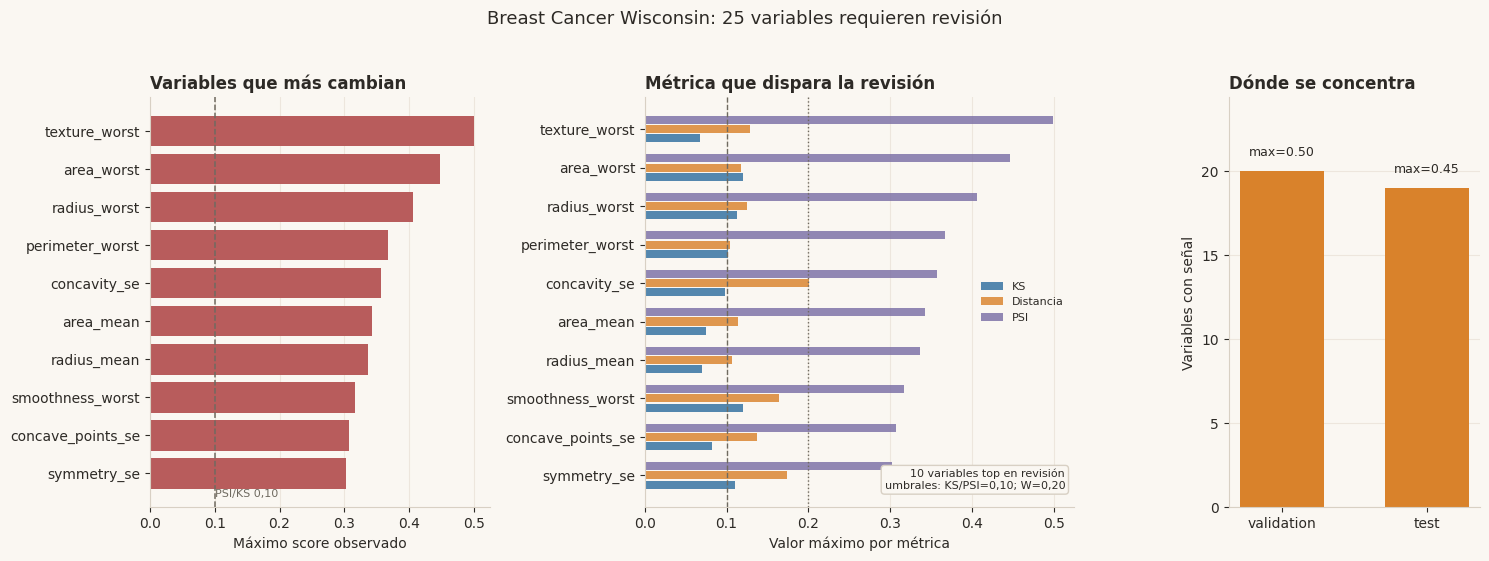

In [65]:
drift_breast_cancer_wisconsin = drift_variables[drift_variables["dataset"].eq("breast_cancer_wisconsin")]
drift_resumen_breast_cancer_wisconsin = drift_resumen[drift_resumen["dataset"].eq("breast_cancer_wisconsin")]
drift_comparaciones_breast_cancer_wisconsin = resumir_drift_comparaciones("breast_cancer_wisconsin")

mostrar_tabla(drift_resumen_breast_cancer_wisconsin, "Resumen drift - Breast Cancer Wisconsin", n=5)
mostrar_tabla(drift_comparaciones_breast_cancer_wisconsin, "Drift por comparación - Breast Cancer Wisconsin", n=5)
mostrar_tabla(drift_breast_cancer_wisconsin.sort_values("drift_score", ascending=False), "Top drift - Breast Cancer Wisconsin", n=15)
graficar_drift_dataset("breast_cancer_wisconsin")


Aparecen 25 variables con señal de revisión y el máximo PSI llega a 0,500. No invalida el split: el AUC adversarial medio es 0,522, pero la selección posterior debe leer estas variables como sensibilidad del particionado.


### Drift Univariante: `customer_churn`


**Resumen drift - Customer Churn** - 1 filas, 6 columnas.

,Dataset,tests,Variables en revisión,PSI máximo,Distancia máxima,max_drift_score
1,customer_churn,20,0,0.000283,0.013087,0.013087


**Drift por comparación - Customer Churn** - 2 filas, 5 columnas.

,Comparación,pruebas,Variables en revisión,max_drift_score,mediana_drift_score
1,validation,10,0,0.007366,0.004527
0,test,10,0,0.013087,0.002654


**Top drift - Customer Churn** - 20 filas, 10 columnas.

,Dataset,Comparación,Variable,Tipo,statistic,p-valor,distancia,PSI,Puntuación de drift,Revisión por drift
73,customer_churn,test,usage_frequency,numerica,0.006247,2.838707e-02,0.013087,0.000238,0.013087,False
64,customer_churn,validation,support_calls,numerica,0.004268,2.736318e-01,0.007366,0.000212,0.007366,False
62,customer_churn,validation,tenure,numerica,0.004266,2.741847e-01,0.006680,0.000085,0.006680,False
63,customer_churn,validation,usage_frequency,numerica,0.003459,5.311964e-01,0.006312,0.000189,0.006312,False
70,customer_churn,test,age,numerica,0.004248,2.785738e-01,0.005629,0.000267,0.005629,False
60,customer_churn,validation,age,numerica,0.004050,3.326315e-01,0.005607,0.000098,0.005607,False
65,customer_churn,validation,payment_delay,numerica,0.003866,3.886462e-01,0.004660,0.000102,0.004660,False
69,customer_churn,validation,last_interaction,numerica,0.002452,8.979579e-01,0.004394,0.000108,0.004394,False
78,customer_churn,test,total_spend,numerica,0.003733,4.328089e-01,0.004390,0.000283,0.004390,False
68,customer_churn,validation,total_spend,numerica,0.003374,5.638055e-01,0.004359,0.000122,0.004359,False


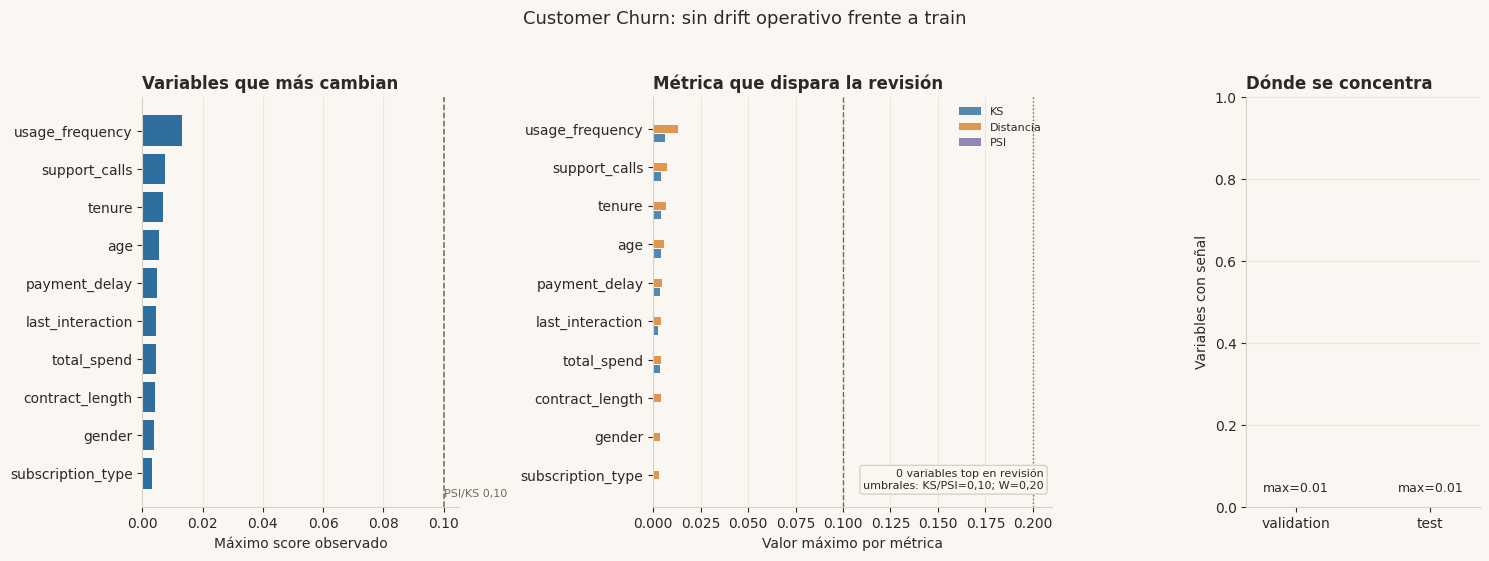

In [66]:
drift_customer_churn = drift_variables[drift_variables["dataset"].eq("customer_churn")]
drift_resumen_customer_churn = drift_resumen[drift_resumen["dataset"].eq("customer_churn")]
drift_comparaciones_customer_churn = resumir_drift_comparaciones("customer_churn")

mostrar_tabla(drift_resumen_customer_churn, "Resumen drift - Customer Churn", n=5)
mostrar_tabla(drift_comparaciones_customer_churn, "Drift por comparación - Customer Churn", n=5)
mostrar_tabla(drift_customer_churn.sort_values("drift_score", ascending=False), "Top drift - Customer Churn", n=15)
graficar_drift_dataset("customer_churn")


No aparece ninguna variable con señal de revisión: máximo PSI 0,0003 y máxima distancia 0,013. Es el split más estable de la fase y pasa a selección sin cautelas distributivas relevantes.


### Drift Univariante: `madelon`


**Resumen drift - Madelon** - 1 filas, 6 columnas.

,Dataset,tests,Variables en revisión,PSI máximo,Distancia máxima,max_drift_score
2,madelon,1000,41,0.181238,0.23536,0.23536


**Drift por comparación - Madelon** - 2 filas, 5 columnas.

,Comparación,pruebas,Variables en revisión,max_drift_score,mediana_drift_score
1,validation,500,21,0.191163,0.079180
0,test,500,24,0.235360,0.076231


**Top drift - Madelon** - 1000 filas, 10 columnas.

,Dataset,Comparación,Variable,Tipo,statistic,p-valor,distancia,PSI,Puntuación de drift,Revisión por drift
664,madelon,test,feat_84,numerica,0.095238,0.021182,0.235360,0.078119,0.235360,True
979,madelon,test,feat_399,numerica,0.118810,0.001709,0.235175,0.110092,0.235175,True
745,madelon,test,feat_165,numerica,0.116905,0.002138,0.213409,0.149931,0.213409,True
935,madelon,test,feat_355,numerica,0.088810,0.038218,0.201258,0.129244,0.201258,True
815,madelon,test,feat_235,numerica,0.086429,0.047061,0.192453,0.084054,0.192453,False
234,madelon,validation,feat_154,numerica,0.081429,0.071530,0.191163,0.052700,0.191163,False
516,madelon,validation,feat_436,numerica,0.087381,0.043331,0.185753,0.093539,0.185753,False
473,madelon,validation,feat_393,numerica,0.090952,0.031537,0.183735,0.048022,0.183735,False
900,madelon,test,feat_320,numerica,0.100000,0.013322,0.181820,0.051755,0.181820,True
375,madelon,validation,feat_295,numerica,0.030476,0.970577,0.076218,0.181238,0.181238,True


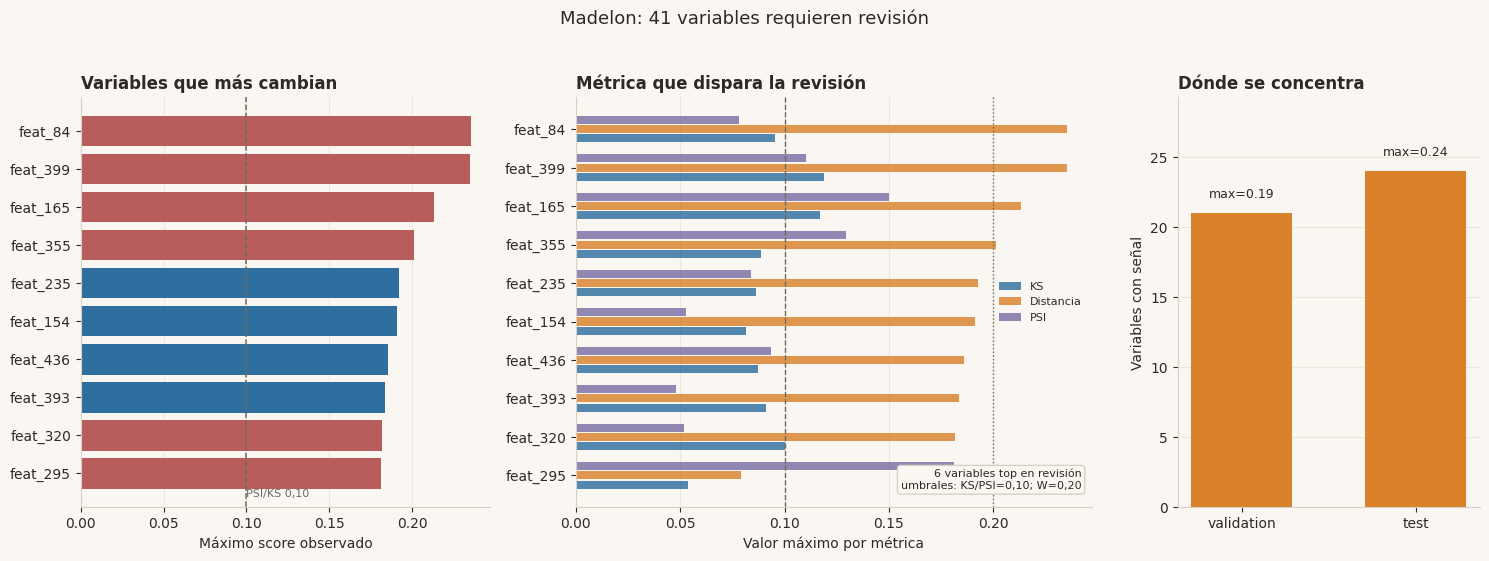

In [67]:
drift_madelon = drift_variables[drift_variables["dataset"].eq("madelon")]
drift_resumen_madelon = drift_resumen[drift_resumen["dataset"].eq("madelon")]
drift_comparaciones_madelon = resumir_drift_comparaciones("madelon")

mostrar_tabla(drift_resumen_madelon, "Resumen drift - Madelon", n=5)
mostrar_tabla(drift_comparaciones_madelon, "Drift por comparación - Madelon", n=5)
mostrar_tabla(drift_madelon.sort_values("drift_score", ascending=False), "Top drift - Madelon", n=15)
graficar_drift_dataset("madelon")


Hay 41 variables con señal de revisión entre 500 y un máximo drift_score de 0,235. En proporción es una alerta acotada, coherente con alta dimensionalidad, y debe cruzarse con estabilidad de selección posterior.


### Drift Univariante: `olive_oil_3class`


**Resumen drift - Olive Oil 3 Clases** - 1 filas, 6 columnas.

,Dataset,tests,Variables en revisión,PSI máximo,Distancia máxima,max_drift_score
3,olive_oil_3class,16,7,0.339128,0.210167,0.339128


**Drift por comparación - Olive Oil 3 Clases** - 2 filas, 5 columnas.

,Comparación,pruebas,Variables en revisión,max_drift_score,mediana_drift_score
1,validation,8,5,0.339128,0.107025
0,test,8,7,0.280999,0.172100


**Top drift - Olive Oil 3 Clases** - 16 filas, 10 columnas.

,Dataset,Comparación,Variable,Tipo,statistic,p-valor,distancia,PSI,Puntuación de drift,Revisión por drift
1083,olive_oil_3class,validation,linoleic,numerica,0.077267,0.757690,0.087395,0.339128,0.339128,True
1090,olive_oil_3class,test,oleic,numerica,0.060581,0.940661,0.120303,0.280999,0.280999,True
1094,olive_oil_3class,test,eicosenoic,numerica,0.102209,0.418392,0.210167,0.257594,0.257594,True
1089,olive_oil_3class,test,stearic,numerica,0.128314,0.176106,0.183181,0.228493,0.228493,True
1082,olive_oil_3class,validation,oleic,numerica,0.114360,0.287202,0.113447,0.184195,0.184195,True
1093,olive_oil_3class,test,arachidic,numerica,0.066512,0.888432,0.156104,0.176670,0.176670,True
1091,olive_oil_3class,test,linoleic,numerica,0.118663,0.248570,0.167530,0.130815,0.167530,True
1080,olive_oil_3class,validation,palmitoleic,numerica,0.058837,0.952605,0.086616,0.155460,0.155460,True
1092,olive_oil_3class,test,linolenic,numerica,0.103140,0.407041,0.141573,0.146887,0.146887,True
1088,olive_oil_3class,test,palmitoleic,numerica,0.083721,0.667627,0.129575,0.114133,0.129575,True


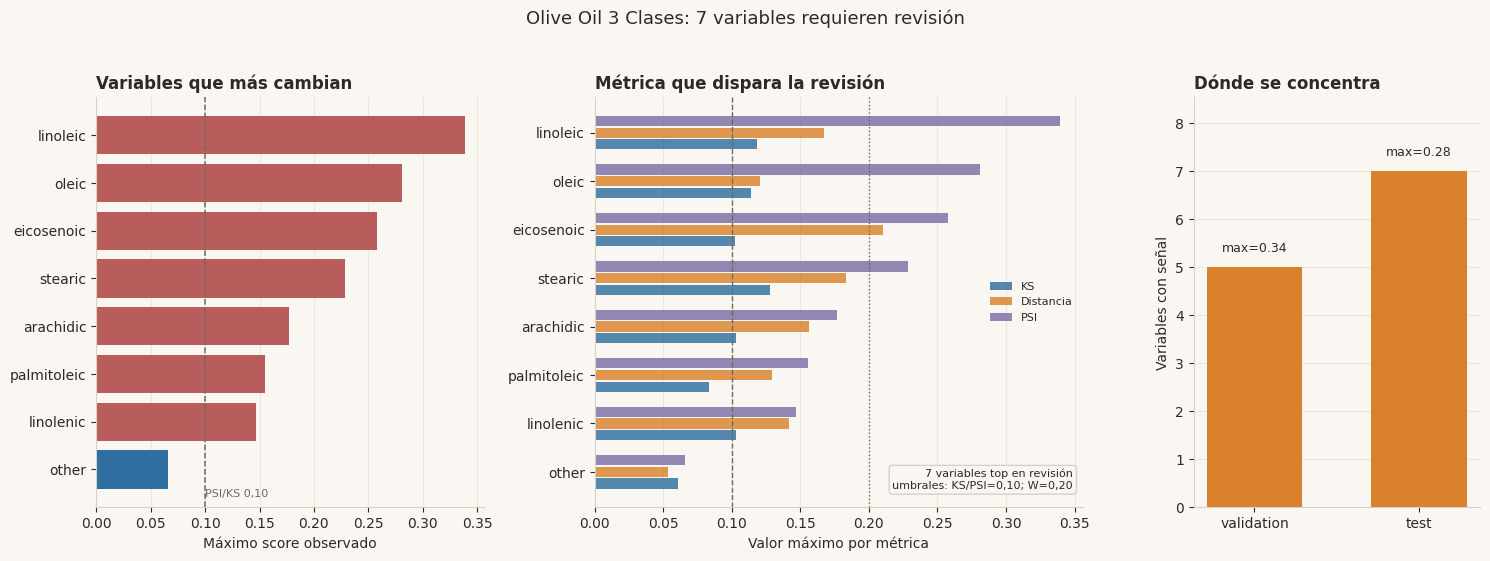

In [68]:
drift_olive_oil_3class = drift_variables[drift_variables["dataset"].eq("olive_oil_3class")]
drift_resumen_olive_oil_3class = drift_resumen[drift_resumen["dataset"].eq("olive_oil_3class")]
drift_comparaciones_olive_oil_3class = resumir_drift_comparaciones("olive_oil_3class")

mostrar_tabla(drift_resumen_olive_oil_3class, "Resumen drift - Olive Oil 3 Clases", n=5)
mostrar_tabla(drift_comparaciones_olive_oil_3class, "Drift por comparación - Olive Oil 3 Clases", n=5)
mostrar_tabla(drift_olive_oil_3class.sort_values("drift_score", ascending=False), "Top drift - Olive Oil 3 Clases", n=15)
graficar_drift_dataset("olive_oil_3class")


Siete de ocho variables muestran señal de revisión, con PSI máximo 0,339 y distancia máxima 0,210. La señal obliga a intervalos prudentes en Fase 6, no a rehacer el split.


### Drift Univariante: `olive_oil_9class`


**Resumen drift - Olive Oil 9 Clases** - 1 filas, 6 columnas.

,Dataset,tests,Variables en revisión,PSI máximo,Distancia máxima,max_drift_score
4,olive_oil_9class,16,6,0.328882,0.163008,0.328882


**Drift por comparación - Olive Oil 9 Clases** - 2 filas, 5 columnas.

,Comparación,pruebas,Variables en revisión,max_drift_score,mediana_drift_score
1,validation,8,4,0.256886,0.108700
0,test,8,5,0.328882,0.144378


**Top drift - Olive Oil 9 Clases** - 16 filas, 10 columnas.

,Dataset,Comparación,Variable,Tipo,statistic,p-valor,distancia,PSI,Puntuación de drift,Revisión por drift
1111,olive_oil_9class,test,other,numerica,0.050058,0.989794,0.091842,0.328882,0.328882,True
1096,olive_oil_9class,validation,palmitoleic,numerica,0.085291,0.645351,0.113177,0.256886,0.256886,True
1109,olive_oil_9class,test,arachidic,numerica,0.075872,0.776817,0.108598,0.180077,0.180077,True
1103,olive_oil_9class,validation,other,numerica,0.078430,0.742285,0.104547,0.179299,0.179299,True
1104,olive_oil_9class,test,palmitoleic,numerica,0.086047,0.634731,0.163008,0.109463,0.163008,True
1099,olive_oil_9class,validation,linoleic,numerica,0.079535,0.726568,0.099888,0.153045,0.153045,True
1105,olive_oil_9class,test,stearic,numerica,0.073605,0.806348,0.149950,0.043142,0.149950,False
1110,olive_oil_9class,test,eicosenoic,numerica,0.087733,0.610774,0.138807,0.101091,0.138807,True
1098,olive_oil_9class,validation,oleic,numerica,0.067267,0.880508,0.094101,0.122768,0.122768,True
1106,olive_oil_9class,test,oleic,numerica,0.057035,0.963352,0.108190,0.107161,0.108190,True


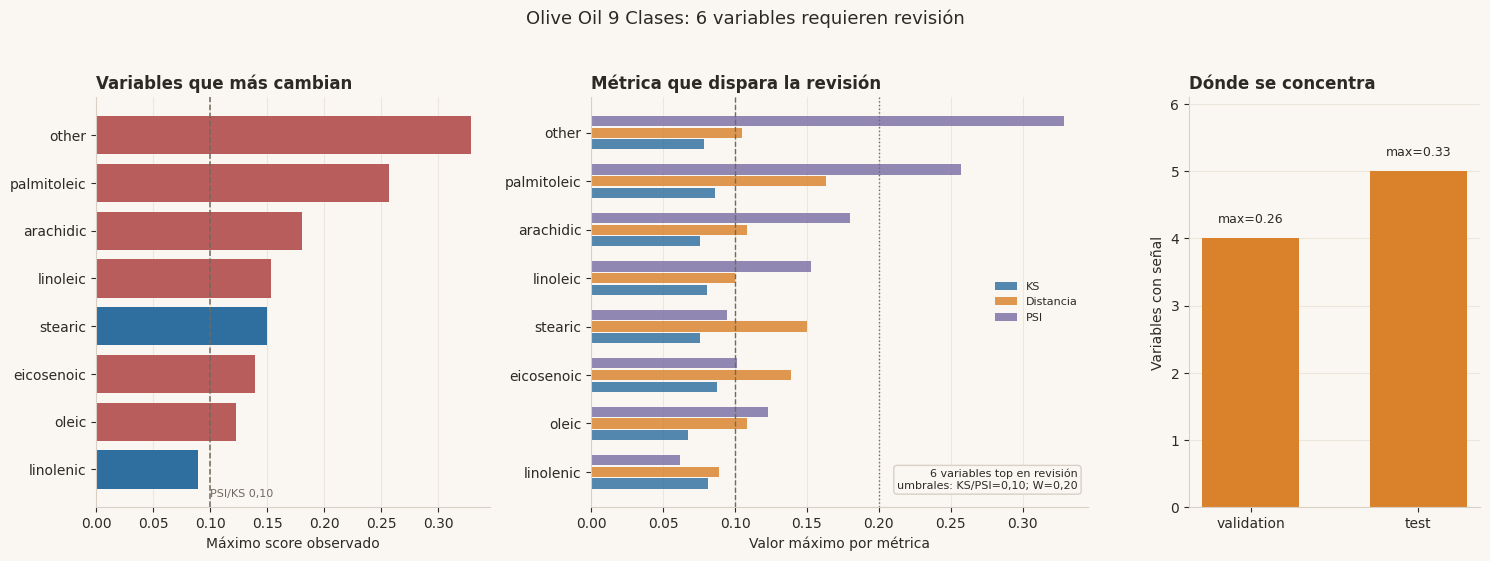

In [69]:
drift_olive_oil_9class = drift_variables[drift_variables["dataset"].eq("olive_oil_9class")]
drift_resumen_olive_oil_9class = drift_resumen[drift_resumen["dataset"].eq("olive_oil_9class")]
drift_comparaciones_olive_oil_9class = resumir_drift_comparaciones("olive_oil_9class")

mostrar_tabla(drift_resumen_olive_oil_9class, "Resumen drift - Olive Oil 9 Clases", n=5)
mostrar_tabla(drift_comparaciones_olive_oil_9class, "Drift por comparación - Olive Oil 9 Clases", n=5)
mostrar_tabla(drift_olive_oil_9class.sort_values("drift_score", ascending=False), "Top drift - Olive Oil 9 Clases", n=15)
graficar_drift_dataset("olive_oil_9class")


Seis de ocho variables muestran señal de revisión, con PSI máximo 0,329 y distancia máxima 0,163. El test de 86 filas y las 9 clases hacen necesaria una lectura por clase en modelado.


## 4.7 Representatividad Multivariante con PCA Exploratorio

PCA se usa como diagnóstico visual de mezcla entre splits. No se aplica como transformación para las fases posteriores. Cada figura combina PC1-PC2 con la varianza explicada de los primeros componentes para no sobreinterpretar una proyección con poca varianza.


In [70]:
def crear_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def columnas_por_tipo(datos_x):
    numericas = [name for name in datos_x.columns if pd.api.types.is_numeric_dtype(datos_x[name])]
    categoricas = [name for name in datos_x.columns if name not in numericas]
    return numericas, categoricas


In [71]:
def crear_preprocesador_modelado(datos_x):
    numericas, categoricas = columnas_por_tipo(datos_x)
    transformers = []
    if numericas:
        transformers.append(("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numericas))
    if categoricas:
        transformers.append(("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", crear_onehot_encoder())]), categoricas))
    return ColumnTransformer(transformers)


def matriz_preprocesada(datos_x):
    preprocessor = crear_preprocesador_modelado(datos_x)
    matriz = preprocessor.fit_transform(datos_x)
    return matriz.toarray() if hasattr(matriz, "toarray") else np.asarray(matriz)


In [72]:
def datos_pca_dataset(nombre_dataset):
    combined_x = unir_x_splits(nombre_dataset)
    sampled_x = muestrear_filas(combined_x, MAX_SAMPLE_PCA)
    matriz = matriz_preprocesada(sampled_x.drop(columns=["split"], errors="ignore"))
    pca = PCA(n_components=min(MAX_PCA_COMPONENTS, matriz.shape[1]), random_state=RANDOM_STATE)
    coords = pca.fit_transform(matriz)
    resultado_pca = {"dataset": nombre_dataset, "sampled_x": sampled_x, "coords": coords, "pca": pca}
    return crear_tablas_pca(resultado_pca)


def unir_x_splits(nombre_dataset):
    frames = []
    for split_name, (x_split, _) in splits_dataset[nombre_dataset].items():
        frames.append(x_split.assign(split=split_name))
    return pd.concat(frames, ignore_index=False)


In [73]:
def muestrear_filas(datos_x, max_rows):
    if len(datos_x) <= max_rows:
        return datos_x.copy()
    muestras = []
    for split_name, parte_split in datos_x.groupby("split", sort=False):
        n_muestra = min(len(parte_split), max_rows // 3)
        muestra = parte_split.sample(n_muestra, random_state=RANDOM_STATE).copy()
        muestra["split"] = split_name
        muestras.append(muestra)
    return pd.concat(muestras, ignore_index=False)


def crear_tablas_pca(resultado_pca):
    coordenadas = pd.DataFrame({
        "dataset": resultado_pca["dataset"],
        "split": resultado_pca["sampled_x"]["split"].to_numpy(),
        "pc1": resultado_pca["coords"][:, 0],
        "pc2": resultado_pca["coords"][:, 1],
    })
    varianza = pd.DataFrame(crear_filas_varianza_pca(resultado_pca["dataset"], resultado_pca["pca"]))
    return coordenadas, varianza


In [74]:
def crear_filas_varianza_pca(nombre_dataset, pca):
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    return [
        {
            "dataset": nombre_dataset,
            "component": component_index + 1,
            "explained_variance_ratio": float(value),
            "cumulative_explained_variance": float(cumulative[component_index]),
        }
        for component_index, value in enumerate(pca.explained_variance_ratio_)
    ]


In [75]:
def graficar_pca_dataset(nombre_dataset):
    coords = pca_coordenadas[pca_coordenadas["dataset"].eq(nombre_dataset)]
    variance = pca_varianza[pca_varianza["dataset"].eq(nombre_dataset)]
    figura, ejes = plt.subplots(1, 2, figsize=(11.2, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})
    for split_name in SPLIT_ORDER:
        subset = coords[coords["split"].eq(split_name)]
        ejes[0].scatter(subset["pc1"], subset["pc2"], s=14, alpha=0.42, color=SPLIT_COLORS[split_name], label=split_name.title())
        ejes[0].scatter(subset["pc1"].mean(), subset["pc2"].mean(), s=90, color=SPLIT_COLORS[split_name], edgecolor="#2D2A26", linewidth=0.8)
    ejes[1].bar(variance["component"], variance["explained_variance_ratio"], color="#2F6F9F")
    cumulative_pc2 = variance.loc[variance["component"].le(2), "explained_variance_ratio"].sum()
    ejes[0].text(
        0.02,
        0.03,
        f"PC1+PC2 explican {cumulative_pc2:.1%}\ncentros marcados con borde",
        transform=ejes[0].transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        bbox={"facecolor": "#FAF7F2", "edgecolor": "#D8D0C4", "boxstyle": "round,pad=0.35"},
    )
    ejes[1].axhline(0.10, color="#6F6A60", linestyle="--", linewidth=1.0)
    ejes[1].text(variance["component"].max(), 0.105, "10% por componente", ha="right", va="bottom", fontsize=8, color="#6F6A60")
    formatear_figura_pca(ejes, nombre_dataset)
    guardar_figura(figura, f"fase4_pca_{nombre_dataset}.png")
    plt.show()


In [76]:
def formatear_figura_pca(ejes, nombre_dataset):
    ejes[0].set_title("PC1-PC2 por split", loc="left", fontweight="bold")
    ejes[0].set_xlabel("PC1")
    ejes[0].set_ylabel("PC2")
    ejes[0].legend(frameon=False)
    ejes[1].set_title("Varianza explicada", loc="left", fontweight="bold")
    ejes[1].set_xlabel("Componente")
    ejes[1].set_ylabel("Ratio")
    for eje in ejes:
        aplicar_estilo_eje(eje, eje_rejilla="both")
    ejes[0].figure.suptitle(f"{etiqueta_dataset(nombre_dataset)}: PCA comprueba mezcla entre splits", fontsize=13, y=1.04)


In [77]:
pca_resultados = {nombre_dataset: datos_pca_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER}
pca_coordenadas = pd.concat([pca_resultados[nombre_dataset][0] for nombre_dataset in DATASET_ORDER], ignore_index=True)
pca_varianza = pd.concat([pca_resultados[nombre_dataset][1] for nombre_dataset in DATASET_ORDER], ignore_index=True)

guardar_tabla(pca_coordenadas, "fase4_pca_coordenadas.csv")
guardar_tabla(pca_varianza, "fase4_pca_varianza.csv")
mostrar_tabla(pca_varianza, "Varianza explicada por PCA", n=25)


**Varianza explicada por PCA** - 25 filas, 4 columnas.

,Dataset,component,explained_variance_ratio,cumulative_explained_variance
0,breast_cancer_wisconsin,1,0.442720,0.442720
1,breast_cancer_wisconsin,2,0.189712,0.632432
2,breast_cancer_wisconsin,3,0.093932,0.726364
3,breast_cancer_wisconsin,4,0.066021,0.792385
4,breast_cancer_wisconsin,5,0.054958,0.847343
5,customer_churn,1,0.168545,0.168545
6,customer_churn,2,0.118610,0.287155
7,customer_churn,3,0.113423,0.400578
8,customer_churn,4,0.108083,0.508662
9,customer_churn,5,0.106742,0.615403


La PCA global muestra cuánto puede leerse de la proyección PC1-PC2: `olive_oil` acumula 68,6% en dos componentes, `breast_cancer_wisconsin` 63,2%, `customer_churn` 28,7% y `madelon` solo 2,3%. Por tanto, una buena mezcla visual en `madelon` no puede tomarse como prueba fuerte de representatividad multivariante, mientras que en `olive_oil` y `breast_cancer_wisconsin` la proyección resume una parte sustancial de la variabilidad.


### PCA Exploratorio: `breast_cancer_wisconsin`


**Varianza PCA - Breast Cancer Wisconsin** - 5 filas, 4 columnas.

,Dataset,component,explained_variance_ratio,cumulative_explained_variance
0,breast_cancer_wisconsin,1,0.442720,0.442720
1,breast_cancer_wisconsin,2,0.189712,0.632432
2,breast_cancer_wisconsin,3,0.093932,0.726364
3,breast_cancer_wisconsin,4,0.066021,0.792385
4,breast_cancer_wisconsin,5,0.054958,0.847343


**Resumen coordenadas PCA - Breast Cancer Wisconsin** - 3 filas, 4 columnas.

,Partición,N,Media CP1,Media CP2
0,test,86,0.055599,0.214682
1,train,398,-0.001862,-0.039369
2,validation,85,-0.047534,-0.032868


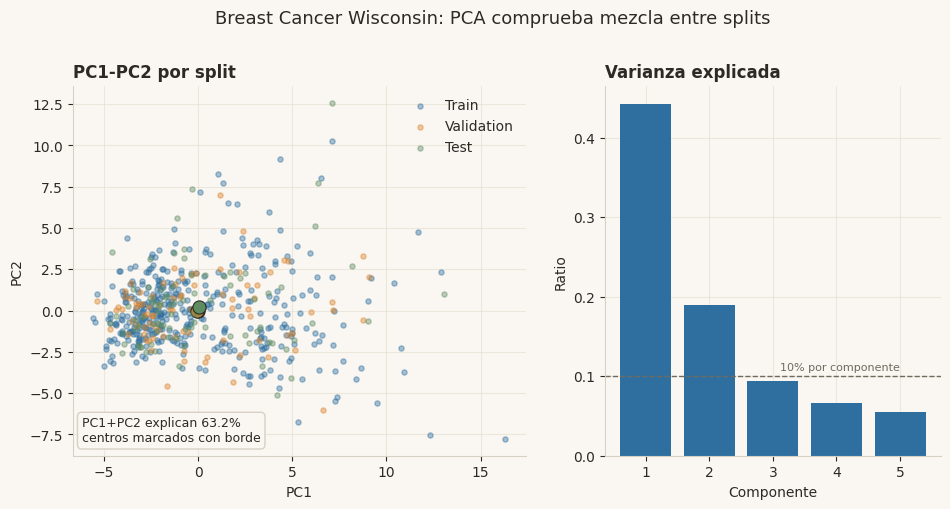

In [78]:
pca_varianza_breast_cancer_wisconsin = pca_varianza[pca_varianza["dataset"].eq("breast_cancer_wisconsin")]
pca_coordenadas_breast_cancer_wisconsin = pca_coordenadas[pca_coordenadas["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(pca_varianza_breast_cancer_wisconsin, "Varianza PCA - Breast Cancer Wisconsin", n=10)
mostrar_tabla(pca_coordenadas_breast_cancer_wisconsin.groupby("split", as_index=False).agg(n=("pc1", "count"), pc1_media=("pc1", "mean"), pc2_media=("pc2", "mean")), "Resumen coordenadas PCA - Breast Cancer Wisconsin", n=10)
graficar_pca_dataset("breast_cancer_wisconsin")


PC1 explica 44,3% y PC2 añade 19,0%, con 63,2% acumulado. La mezcla visual se puede leer con más confianza que en `madelon`, aunque no resume el 100% del espacio.


### PCA Exploratorio: `customer_churn`


**Varianza PCA - Customer Churn** - 5 filas, 4 columnas.

,Dataset,component,explained_variance_ratio,cumulative_explained_variance
5,customer_churn,1,0.168545,0.168545
6,customer_churn,2,0.118610,0.287155
7,customer_churn,3,0.113423,0.400578
8,customer_churn,4,0.108083,0.508662
9,customer_churn,5,0.106742,0.615403


**Resumen coordenadas PCA - Customer Churn** - 3 filas, 4 columnas.

,Partición,N,Media CP1,Media CP2
0,test,2000,-0.000228,-0.010548
1,train,2000,0.016280,0.010143
2,validation,2000,-0.016052,0.000404


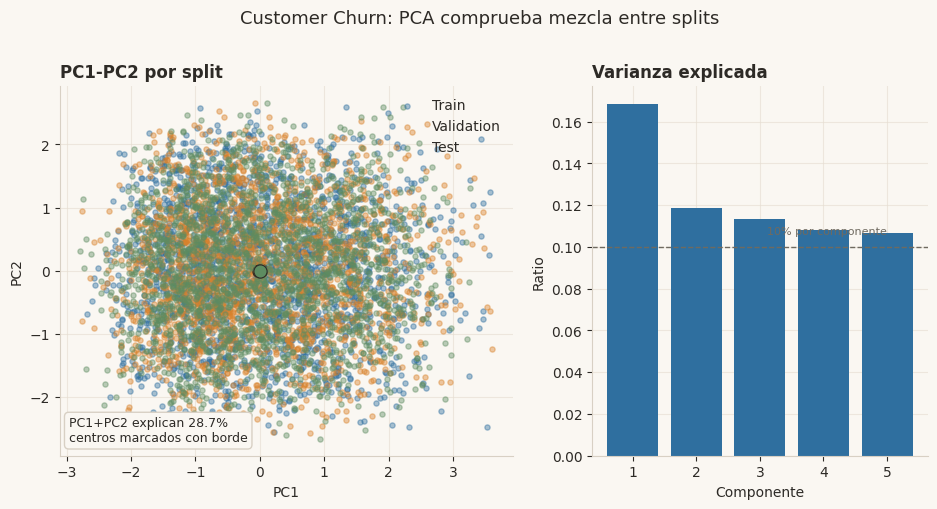

In [79]:
pca_varianza_customer_churn = pca_varianza[pca_varianza["dataset"].eq("customer_churn")]
pca_coordenadas_customer_churn = pca_coordenadas[pca_coordenadas["dataset"].eq("customer_churn")]

mostrar_tabla(pca_varianza_customer_churn, "Varianza PCA - Customer Churn", n=10)
mostrar_tabla(pca_coordenadas_customer_churn.groupby("split", as_index=False).agg(n=("pc1", "count"), pc1_media=("pc1", "mean"), pc2_media=("pc2", "mean")), "Resumen coordenadas PCA - Customer Churn", n=10)
graficar_pca_dataset("customer_churn")


La PCA usa una muestra visual de 6.000 filas frente a 440.832 totales. PC1-PC2 acumulan 28,7%, suficiente para detectar separaciones gruesas pero no para descartar cambios sutiles.


### PCA Exploratorio: `madelon`


**Varianza PCA - Madelon** - 5 filas, 4 columnas.

,Dataset,component,explained_variance_ratio,cumulative_explained_variance
10,madelon,1,0.012926,0.012926
11,madelon,2,0.010048,0.022975
12,madelon,3,0.008647,0.031622
13,madelon,4,0.006273,0.037895
14,madelon,5,0.004991,0.042886


**Resumen coordenadas PCA - Madelon** - 3 filas, 4 columnas.

,Partición,N,Media CP1,Media CP2
0,test,300,0.006263,-0.022423
1,train,1400,-0.058472,-0.014161
2,validation,300,0.266607,0.088506


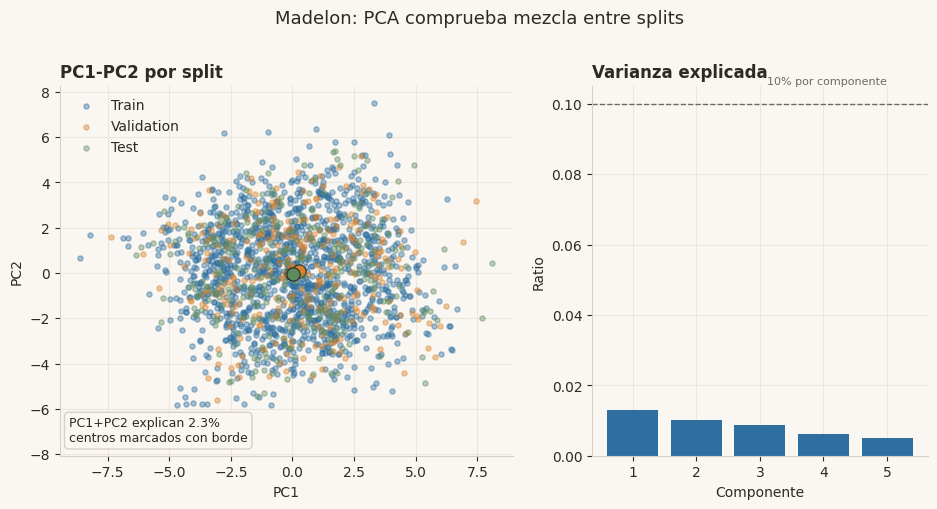

In [80]:
pca_varianza_madelon = pca_varianza[pca_varianza["dataset"].eq("madelon")]
pca_coordenadas_madelon = pca_coordenadas[pca_coordenadas["dataset"].eq("madelon")]

mostrar_tabla(pca_varianza_madelon, "Varianza PCA - Madelon", n=10)
mostrar_tabla(pca_coordenadas_madelon.groupby("split", as_index=False).agg(n=("pc1", "count"), pc1_media=("pc1", "mean"), pc2_media=("pc2", "mean")), "Resumen coordenadas PCA - Madelon", n=10)
graficar_pca_dataset("madelon")


PC1-PC2 acumulan solo 2,3% de la varianza. Aunque los splits parezcan mezclados, la proyección pierde casi todo el espacio de 500 variables.


### PCA Exploratorio: `olive_oil_3class`


**Varianza PCA - Olive Oil 3 Clases** - 5 filas, 4 columnas.

,Dataset,component,explained_variance_ratio,cumulative_explained_variance
15,olive_oil_3class,1,0.465176,0.465176
16,olive_oil_3class,2,0.220725,0.685901
17,olive_oil_3class,3,0.127044,0.812945
18,olive_oil_3class,4,0.099112,0.912058
19,olive_oil_3class,5,0.041727,0.953785


**Resumen coordenadas PCA - Olive Oil 3 Clases** - 3 filas, 4 columnas.

,Partición,N,Media CP1,Media CP2
0,test,86,0.255840,0.000857
1,train,400,-0.028287,-0.006777
2,validation,86,-0.124273,0.030666


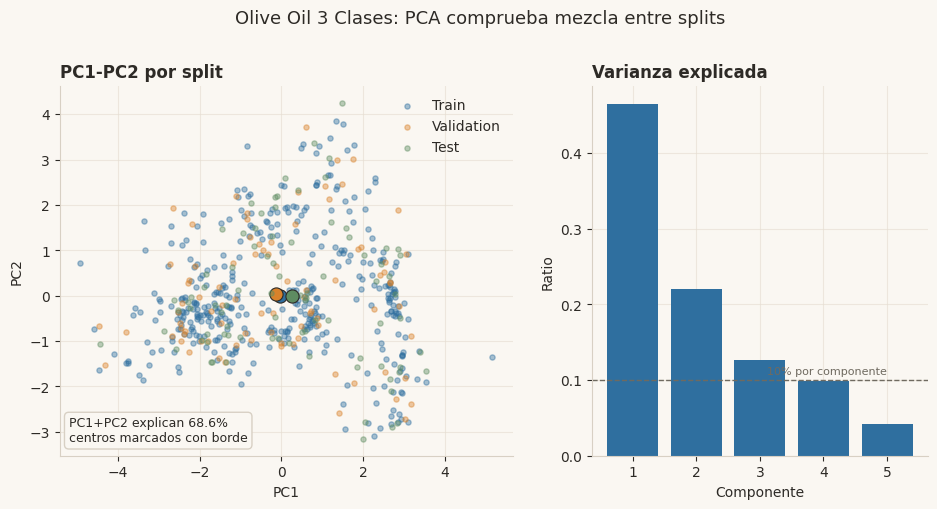

In [81]:
pca_varianza_olive_oil_3class = pca_varianza[pca_varianza["dataset"].eq("olive_oil_3class")]
pca_coordenadas_olive_oil_3class = pca_coordenadas[pca_coordenadas["dataset"].eq("olive_oil_3class")]

mostrar_tabla(pca_varianza_olive_oil_3class, "Varianza PCA - Olive Oil 3 Clases", n=10)
mostrar_tabla(pca_coordenadas_olive_oil_3class.groupby("split", as_index=False).agg(n=("pc1", "count"), pc1_media=("pc1", "mean"), pc2_media=("pc2", "mean")), "Resumen coordenadas PCA - Olive Oil 3 Clases", n=10)
graficar_pca_dataset("olive_oil_3class")


PC1-PC2 acumulan 68,6% de la varianza tras excluir proxies. La figura permite revisar si train, validation o test quedan separados por composición química.


### PCA Exploratorio: `olive_oil_9class`


**Varianza PCA - Olive Oil 9 Clases** - 5 filas, 4 columnas.

,Dataset,component,explained_variance_ratio,cumulative_explained_variance
20,olive_oil_9class,1,0.465176,0.465176
21,olive_oil_9class,2,0.220725,0.685901
22,olive_oil_9class,3,0.127044,0.812945
23,olive_oil_9class,4,0.099112,0.912058
24,olive_oil_9class,5,0.041727,0.953785


**Resumen coordenadas PCA - Olive Oil 9 Clases** - 3 filas, 4 columnas.

,Partición,N,Media CP1,Media CP2
0,test,86,0.189631,0.033453
1,train,400,-0.014543,0.005776
2,validation,86,-0.121988,-0.060318


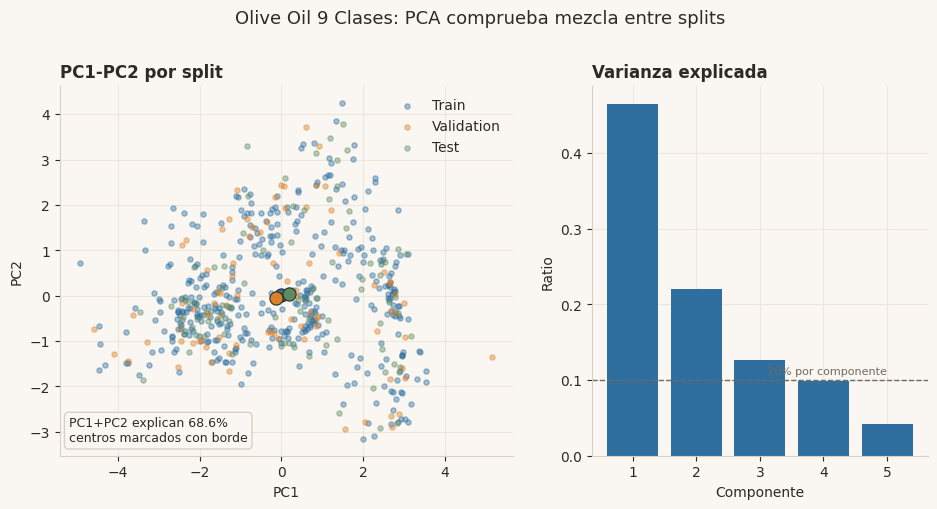

In [82]:
pca_varianza_olive_oil_9class = pca_varianza[pca_varianza["dataset"].eq("olive_oil_9class")]
pca_coordenadas_olive_oil_9class = pca_coordenadas[pca_coordenadas["dataset"].eq("olive_oil_9class")]

mostrar_tabla(pca_varianza_olive_oil_9class, "Varianza PCA - Olive Oil 9 Clases", n=10)
mostrar_tabla(pca_coordenadas_olive_oil_9class.groupby("split", as_index=False).agg(n=("pc1", "count"), pc1_media=("pc1", "mean"), pc2_media=("pc2", "mean")), "Resumen coordenadas PCA - Olive Oil 9 Clases", n=10)
graficar_pca_dataset("olive_oil_9class")


La varianza PC1-PC2 también acumula 68,6%, porque usa las mismas 8 variables químicas. La proyección diagnostica representatividad, no separabilidad garantizada de 9 clases.


## 4.8 Auditoría de Leakage y Proxies Después del Split

Se comprueba que el target no esté en `X`, se buscan nombres sospechosos y se calcula asociación univariante extrema. En variables binarias se usa AUC absoluto; en todos los targets se usa NMI como señal de dependencia casi perfecta.


In [83]:
def discretizar_para_nmi(serie_variable):
    if not pd.api.types.is_numeric_dtype(serie_variable):
        return serie_variable.astype(str)
    try:
        return pd.qcut(serie_variable.rank(method="first"), q=min(10, serie_variable.nunique()), duplicates="drop").astype(str)
    except ValueError:
        return serie_variable.astype(str)


def calcular_nmi_variable(serie_variable, serie_target):
    variable_discreta = discretizar_para_nmi(serie_variable)
    return normalized_mutual_info_score(serie_target.astype(str), variable_discreta.astype(str))


def obtener_muestra_leakage(nombre_dataset):
    x_dataset, y_dataset = datasets_xy[nombre_dataset]
    if len(y_dataset) <= MAX_SAMPLE_LEAKAGE:
        return x_dataset, y_dataset
    sampled_index = y_dataset.sample(MAX_SAMPLE_LEAKAGE, random_state=RANDOM_STATE).index
    return x_dataset.loc[sampled_index], y_dataset.loc[sampled_index]


In [84]:
def evaluar_leakage_variable(nombre_dataset, variable_name):
    x_dataset, y_dataset = muestras_leakage[nombre_dataset]
    serie_variable = x_dataset[variable_name]
    return {
        "dataset": nombre_dataset,
        "variable": variable_name,
        "nombre_sospechoso": detectar_nombre_sospechoso(nombre_dataset, variable_name),
        "auc_abs_binaria": calcular_auc_binaria(serie_variable, y_dataset),
        "nmi_con_target": calcular_nmi_variable(serie_variable, y_dataset),
        "unique_ratio": serie_variable.nunique(dropna=False) / len(serie_variable),
    }


def detectar_nombre_sospechoso(nombre_dataset, variable_name):
    tokens = [TARGET_BY_DATASET[nombre_dataset], "target", "label", "class", "clase"]
    return any(token.lower() in variable_name.lower() for token in tokens)


In [85]:
def resumir_leakage_dataset(nombre_dataset):
    screening = leakage_screening[leakage_screening["dataset"].eq(nombre_dataset)]
    x_dataset = datasets_xy[nombre_dataset][0]
    return {
        "dataset": nombre_dataset,
        "target_en_X": TARGET_BY_DATASET[nombre_dataset] in x_dataset.columns,
        "n_muestras_usadas": len(muestras_leakage[nombre_dataset][1]),
        "nombres_sospechosos": int(screening["nombre_sospechoso"].sum()),
        "auc_abs_ge_099": int((screening["auc_abs_binaria"] >= AUC_LEAKAGE_REVIEW_THRESHOLD).sum()),
        "nmi_ge_099": int((screening["nmi_con_target"] >= NMI_LEAKAGE_REVIEW_THRESHOLD).sum()),
        "categoricas_en_X": int(resumen_xy.loc[resumen_xy["dataset"].eq(nombre_dataset), "categoricas_en_X"].iloc[0]),
    }


In [86]:
muestras_leakage = {nombre_dataset: obtener_muestra_leakage(nombre_dataset) for nombre_dataset in DATASET_ORDER}

leakage_screening = pd.DataFrame([
    evaluar_leakage_variable(nombre_dataset, variable_name)
    for nombre_dataset in DATASET_ORDER
    for variable_name in datasets_xy[nombre_dataset][0].columns
])

leakage_resumen = pd.DataFrame([resumir_leakage_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER])

guardar_tabla(leakage_screening, "fase4_leakage_screening.csv")
guardar_tabla(leakage_resumen, "fase4_leakage_resumen.csv")
mostrar_tabla(leakage_resumen, "Resumen leakage/proxy", n=10)
mostrar_tabla(leakage_screening.sort_values("nmi_con_target", ascending=False), "Variables con mayor NMI con target", n=20)


**Resumen leakage/proxy** - 5 filas, 7 columnas.

,Dataset,Objetivo dentro de X,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",categoricas_en_X
0,breast_cancer_wisconsin,False,569,0,0,0,0
1,customer_churn,False,12000,0,0,0,3
2,madelon,False,2000,0,0,0,0
3,olive_oil_3class,False,572,0,0,0,0
4,olive_oil_9class,False,572,0,0,0,0


**Variables con mayor NMI con target** - 556 filas, 6 columnas.

,Dataset,Variable,nombre_sospechoso,auc_abs_binaria,NMI con objetivo,unique_ratio
551,olive_oil_9class,linoleic,False,NaN,0.470723,0.680070
552,olive_oil_9class,linolenic,False,NaN,0.465709,0.601399
547,olive_oil_3class,other,False,NaN,0.432788,0.076923
549,olive_oil_9class,stearic,False,NaN,0.420695,0.305944
555,olive_oil_9class,other,False,NaN,0.414185,0.076923
548,olive_oil_9class,palmitoleic,False,NaN,0.352411,0.540210
22,breast_cancer_wisconsin,perimeter_worst,False,0.975451,0.318467,0.903339
20,breast_cancer_wisconsin,radius_worst,False,0.970443,0.309825,0.803163
23,breast_cancer_wisconsin,area_worst,False,0.969828,0.308642,0.956063
27,breast_cancer_wisconsin,concave_points_worst,False,0.966704,0.300960,0.864675


La pantalla global de leakage no detecta proxies extremos en las variables que permanecen en `X`: los 5 datasets tienen `target_en_X=False`, 0 nombres sospechosos y 0 variables con NMI >= 0,99. La cautela relevante queda documentada fuera de `X`, porque `palmitic` alcanza NMI 1,000 con `target` en `olive_oil_9class` y por eso fue excluida antes del split.


### Leakage y Proxies: `breast_cancer_wisconsin`


In [87]:
leakage_breast_cancer_wisconsin = leakage_screening[leakage_screening["dataset"].eq("breast_cancer_wisconsin")]
leakage_resumen_breast_cancer_wisconsin = leakage_resumen[leakage_resumen["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(leakage_resumen_breast_cancer_wisconsin, "Resumen leakage - Breast Cancer Wisconsin", n=5)
mostrar_tabla(leakage_breast_cancer_wisconsin.sort_values("nmi_con_target", ascending=False), "Screening leakage - Breast Cancer Wisconsin", n=15)


**Resumen leakage - Breast Cancer Wisconsin** - 1 filas, 7 columnas.

,Dataset,Objetivo dentro de X,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",categoricas_en_X
0,breast_cancer_wisconsin,False,569,0,0,0,0


**Screening leakage - Breast Cancer Wisconsin** - 30 filas, 6 columnas.

,Dataset,Variable,nombre_sospechoso,auc_abs_binaria,NMI con objetivo,unique_ratio
22,breast_cancer_wisconsin,perimeter_worst,False,0.975451,0.318467,0.903339
20,breast_cancer_wisconsin,radius_worst,False,0.970443,0.309825,0.803163
23,breast_cancer_wisconsin,area_worst,False,0.969828,0.308642,0.956063
27,breast_cancer_wisconsin,concave_points_worst,False,0.966704,0.300960,0.864675
7,breast_cancer_wisconsin,concave_points_mean,False,0.964438,0.292613,0.952548
2,breast_cancer_wisconsin,perimeter_mean,False,0.946898,0.264031,0.917399
3,breast_cancer_wisconsin,area_mean,False,0.938316,0.259357,0.947276
0,breast_cancer_wisconsin,radius_mean,False,0.937517,0.256097,0.801406
6,breast_cancer_wisconsin,concavity_mean,False,0.937827,0.245359,0.943761
13,breast_cancer_wisconsin,area_se,False,0.926411,0.239533,0.927944


El resumen marca `target_en_X=False`, 0 nombres sospechosos, 0 variables con AUC >= 0,99 y 0 con NMI >= 0,99. Las asociaciones predictivas no se interpretan como leakage si no codifican el target por diseño.


### Leakage y Proxies: `customer_churn`


In [88]:
leakage_customer_churn = leakage_screening[leakage_screening["dataset"].eq("customer_churn")]
leakage_resumen_customer_churn = leakage_resumen[leakage_resumen["dataset"].eq("customer_churn")]

mostrar_tabla(leakage_resumen_customer_churn, "Resumen leakage - Customer Churn", n=5)
mostrar_tabla(leakage_customer_churn.sort_values("nmi_con_target", ascending=False), "Screening leakage - Customer Churn", n=15)


**Resumen leakage - Customer Churn** - 1 filas, 7 columnas.

,Dataset,Objetivo dentro de X,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",categoricas_en_X
1,customer_churn,False,12000,0,0,0,3


**Screening leakage - Customer Churn** - 10 filas, 6 columnas.

,Dataset,Variable,nombre_sospechoso,auc_abs_binaria,NMI con objetivo,unique_ratio
34,customer_churn,support_calls,False,0.819089,0.154361,0.000917
37,customer_churn,contract_length,False,0.504525,0.146468,0.000250
38,customer_churn,total_spend,False,0.728532,0.105413,0.582500
35,customer_churn,payment_delay,False,0.676205,0.078529,0.002583
30,customer_churn,age,False,0.610765,0.073471,0.004000
31,customer_churn,gender,False,0.585937,0.021762,0.000167
39,customer_churn,last_interaction,False,0.590613,0.009910,0.002500
32,customer_churn,tenure,False,0.518777,0.001231,0.005000
33,customer_churn,usage_frequency,False,0.522242,0.001161,0.002500
36,customer_churn,subscription_type,False,0.515151,0.000431,0.000250


El screening usa 12.000 muestras y mantiene 3 categóricas en `X`; aun así, hay 0 nombres sospechosos y 0 variables con NMI >= 0,99. La codificación queda para el modelado posterior.


### Leakage y Proxies: `madelon`


In [89]:
leakage_madelon = leakage_screening[leakage_screening["dataset"].eq("madelon")]
leakage_resumen_madelon = leakage_resumen[leakage_resumen["dataset"].eq("madelon")]

mostrar_tabla(leakage_resumen_madelon, "Resumen leakage - Madelon", n=5)
mostrar_tabla(leakage_madelon.sort_values("nmi_con_target", ascending=False), "Screening leakage - Madelon", n=15)


**Resumen leakage - Madelon** - 1 filas, 7 columnas.

,Dataset,Objetivo dentro de X,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",categoricas_en_X
2,madelon,False,2000,0,0,0,0


**Screening leakage - Madelon** - 500 filas, 6 columnas.

,Dataset,Variable,nombre_sospechoso,auc_abs_binaria,NMI con objetivo,unique_ratio
378,madelon,feat_338,False,0.581902,0.020653,0.2125
515,madelon,feat_475,False,0.630268,0.020350,0.1585
281,madelon,feat_241,False,0.631048,0.020115,0.1190
145,madelon,feat_105,False,0.576058,0.014610,0.2760
376,madelon,feat_336,False,0.597747,0.012381,0.2300
168,madelon,feat_128,False,0.577463,0.011080,0.0350
104,madelon,feat_64,False,0.595610,0.010843,0.2010
512,madelon,feat_472,False,0.561761,0.009449,0.1085
482,madelon,feat_442,False,0.562215,0.009423,0.2140
493,madelon,feat_453,False,0.557114,0.006765,0.2425


La revisión cubre 2.000 muestras y 500 variables, con 0 nombres sospechosos y 0 proxies extremos. La selección real se aplaza a la etapa posterior.


### Leakage y Proxies: `olive_oil_3class`


In [90]:
leakage_olive_oil_3class = leakage_screening[leakage_screening["dataset"].eq("olive_oil_3class")]
leakage_resumen_olive_oil_3class = leakage_resumen[leakage_resumen["dataset"].eq("olive_oil_3class")]

mostrar_tabla(leakage_resumen_olive_oil_3class, "Resumen leakage - Olive Oil 3 Clases", n=5)
mostrar_tabla(leakage_olive_oil_3class.sort_values("nmi_con_target", ascending=False), "Screening leakage - Olive Oil 3 Clases", n=15)


**Resumen leakage - Olive Oil 3 Clases** - 1 filas, 7 columnas.

,Dataset,Objetivo dentro de X,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",categoricas_en_X
3,olive_oil_3class,False,572,0,0,0,0


**Screening leakage - Olive Oil 3 Clases** - 8 filas, 6 columnas.

,Dataset,Variable,nombre_sospechoso,auc_abs_binaria,NMI con objetivo,unique_ratio
547,olive_oil_3class,other,False,NaN,0.432788,0.076923
543,olive_oil_3class,linoleic,False,NaN,0.291447,0.680070
540,olive_oil_3class,palmitoleic,False,NaN,0.254456,0.540210
544,olive_oil_3class,linolenic,False,NaN,0.240267,0.601399
541,olive_oil_3class,stearic,False,NaN,0.238201,0.305944
545,olive_oil_3class,arachidic,False,NaN,0.201753,0.078671
546,olive_oil_3class,eicosenoic,False,NaN,0.178381,0.132867
542,olive_oil_3class,oleic,False,NaN,0.051773,0.241259


`palmitic` no aparece en `X`; el resumen deja 0 variables con NMI >= 0,99 entre las 8 predictoras. La métrica excluida explica por qué no debe entrar en la formulación.


### Leakage y Proxies: `olive_oil_9class`


In [91]:
leakage_olive_oil_9class = leakage_screening[leakage_screening["dataset"].eq("olive_oil_9class")]
leakage_resumen_olive_oil_9class = leakage_resumen[leakage_resumen["dataset"].eq("olive_oil_9class")]

mostrar_tabla(leakage_resumen_olive_oil_9class, "Resumen leakage - Olive Oil 9 Clases", n=5)
mostrar_tabla(leakage_olive_oil_9class.sort_values("nmi_con_target", ascending=False), "Screening leakage - Olive Oil 9 Clases", n=15)


**Resumen leakage - Olive Oil 9 Clases** - 1 filas, 7 columnas.

,Dataset,Objetivo dentro de X,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",categoricas_en_X
4,olive_oil_9class,False,572,0,0,0,0


**Screening leakage - Olive Oil 9 Clases** - 8 filas, 6 columnas.

,Dataset,Variable,nombre_sospechoso,auc_abs_binaria,NMI con objetivo,unique_ratio
551,olive_oil_9class,linoleic,False,NaN,0.470723,0.680070
552,olive_oil_9class,linolenic,False,NaN,0.465709,0.601399
549,olive_oil_9class,stearic,False,NaN,0.420695,0.305944
555,olive_oil_9class,other,False,NaN,0.414185,0.076923
548,olive_oil_9class,palmitoleic,False,NaN,0.352411,0.540210
553,olive_oil_9class,arachidic,False,NaN,0.299011,0.078671
554,olive_oil_9class,eicosenoic,False,NaN,0.264648,0.132867
550,olive_oil_9class,oleic,False,NaN,0.205725,0.241259


La exclusión de `area` y `palmitic` deja 8 predictoras y 0 proxies NMI >= 0,99. La tabla de excluidas conserva la evidencia del proxy perfecto sin contaminar `X`.


## 4.9 Validación Adversarial Train vs Test

La validación adversarial intenta distinguir filas de `train` frente a filas de `test`. Un AUC cercano a 0.5 sugiere particiones difíciles de distinguir; valores altos indican posible cambio de distribución que debe leerse junto con drift y PCA.


In [92]:
def preparar_adversarial_dataset(nombre_dataset):
    train_x = splits_dataset[nombre_dataset]["train"][0].assign(origen_split=0)
    test_x = splits_dataset[nombre_dataset]["test"][0].assign(origen_split=1)
    combined = pd.concat([train_x, test_x], ignore_index=True)
    sampled = muestrear_adversarial(combined)
    y_adv = sampled.pop("origen_split")
    return sampled, y_adv


def muestrear_adversarial(datos_adversarial):
    if len(datos_adversarial) <= MAX_SAMPLE_ADVERSARIAL:
        return datos_adversarial.copy()
    muestras = []
    for origen_split, parte_origen in datos_adversarial.groupby("origen_split", sort=False):
        muestra = parte_origen.sample(MAX_SAMPLE_ADVERSARIAL // 2, random_state=RANDOM_STATE).copy()
        muestra["origen_split"] = origen_split
        muestras.append(muestra)
    return pd.concat(muestras, ignore_index=True)


In [93]:
def crear_pipeline_adversarial(datos_x):
    preprocessor = crear_preprocesador_modelado(datos_x)
    model = LogisticRegression(max_iter=600, solver="liblinear", random_state=RANDOM_STATE)
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def evaluar_adversarial_dataset(nombre_dataset):
    x_adv, y_adv = preparar_adversarial_dataset(nombre_dataset)
    pipeline = crear_pipeline_adversarial(x_adv)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, x_adv, y_adv, cv=cv, scoring="roc_auc")
    metricas = {"dataset": nombre_dataset, "scores": scores, "filas": len(x_adv), "features": x_adv.shape[1]}
    return crear_resultado_adversarial(metricas)


In [94]:
def crear_resultado_adversarial(metricas_adversarial):
    scores = metricas_adversarial["scores"]
    return {
        "dataset": metricas_adversarial["dataset"],
        "auc_cv": float(np.mean(scores)),
        "auc_fold_std": float(np.std(scores, ddof=1)),
        "auc_min": float(np.min(scores)),
        "auc_max": float(np.max(scores)),
        "n_muestras_usadas": metricas_adversarial["filas"],
        "features_usadas": metricas_adversarial["features"],
    }


def crear_filas_folds_adversarial(nombre_dataset, scores):
    return [{"dataset": nombre_dataset, "fold": fold + 1, "auc": score} for fold, score in enumerate(scores)]


In [95]:
def evaluar_folds_adversarial_dataset(nombre_dataset):
    x_adv, y_adv = preparar_adversarial_dataset(nombre_dataset)
    pipeline = crear_pipeline_adversarial(x_adv)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, x_adv, y_adv, cv=cv, scoring="roc_auc")
    return crear_filas_folds_adversarial(nombre_dataset, scores)


In [96]:
adversarial_resultados = pd.DataFrame([evaluar_adversarial_dataset(nombre_dataset) for nombre_dataset in DATASET_ORDER])
adversarial_folds = pd.DataFrame([row for nombre_dataset in DATASET_ORDER for row in evaluar_folds_adversarial_dataset(nombre_dataset)])

guardar_tabla(adversarial_resultados, "fase4_validacion_adversarial.csv")
guardar_tabla(adversarial_folds, "fase4_validacion_adversarial_folds.csv")
mostrar_tabla(adversarial_resultados, "Validación adversarial train vs test", n=10)
mostrar_tabla(adversarial_folds, "AUC por fold", n=25)


**Validación adversarial train vs test** - 5 filas, 7 columnas.

,Dataset,AUC medio,Desviación AUC,auc_min,auc_max,n_muestras_usadas,features_usadas
0,breast_cancer_wisconsin,0.522322,0.077790,0.452206,0.655249,484,30
1,customer_churn,0.516379,0.012585,0.497112,0.526705,12000,10
2,madelon,0.475976,0.053592,0.390655,0.525893,1700,500
3,olive_oil_3class,0.513350,0.058767,0.461029,0.607353,486,8
4,olive_oil_9class,0.535025,0.059244,0.457353,0.622917,486,8


**AUC por fold** - 25 filas, 3 columnas.

,Dataset,Fold,AUC
0,breast_cancer_wisconsin,1,0.511029
1,breast_cancer_wisconsin,2,0.452206
2,breast_cancer_wisconsin,3,0.487500
3,breast_cancer_wisconsin,4,0.505626
4,breast_cancer_wisconsin,5,0.655249
5,customer_churn,1,0.497112
6,customer_churn,2,0.526705
7,customer_churn,3,0.521553
8,customer_churn,4,0.510457
9,customer_churn,5,0.526066


La validación adversarial queda cerca de la banda de azar en los 5 datasets: los AUC medios van de 0,500 en `madelon` a 0,535 en `olive_oil_9class`. Esa lectura refuerza que las diferencias entre train y test no forman una separación fácil para un clasificador auxiliar.


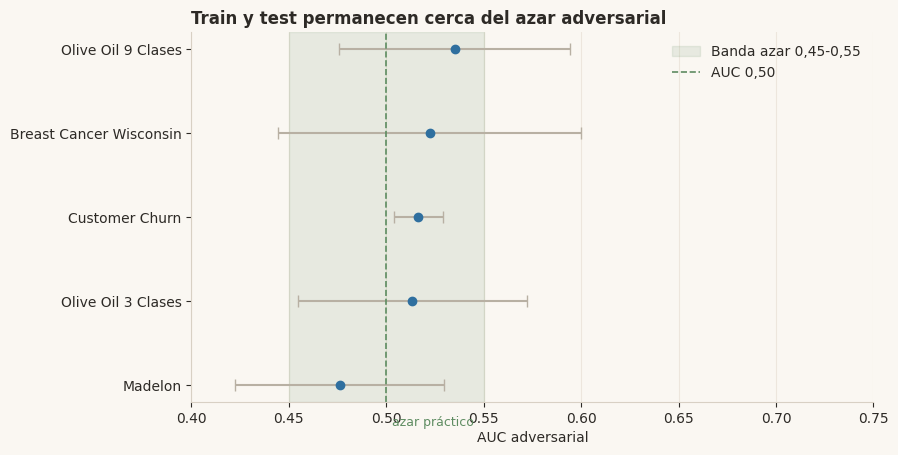

In [97]:
figura, eje = plt.subplots(figsize=(8.8, 4.8))
ordered_adv = adversarial_resultados.sort_values("auc_cv")
eje.axvspan(0.45, 0.55, color="#5E8C61", alpha=0.12, label="Banda azar 0,45-0,55")
eje.errorbar(ordered_adv["auc_cv"], [etiqueta_dataset(name) for name in ordered_adv["dataset"]], xerr=ordered_adv["auc_fold_std"], fmt="o", color="#2F6F9F", ecolor="#B8B0A3", capsize=4)
eje.axvline(0.5, color="#5E8C61", linestyle="--", linewidth=1.2, label="AUC 0,50")
eje.set_xlim(0.40, max(0.75, ordered_adv["auc_cv"].max() + 0.05))
eje.set_xlabel("AUC adversarial")
eje.set_title("Train y test permanecen cerca del azar adversarial", loc="left", fontweight="bold")
eje.text(
    0.545,
    -0.45,
    "azar práctico",
    ha="right",
    va="center",
    fontsize=9,
    color="#5E8C61",
)
eje.legend(frameon=False)
aplicar_estilo_eje(eje, eje_rejilla="x")
guardar_figura(figura, "fase4_validacion_adversarial_auc.png")
plt.show()


La validación adversarial queda dentro de una banda compatible con azar práctico: los AUC medios van de 0,476 en `madelon` a 0,535 en `olive_oil_9class`, con línea de referencia en 0,500 y desviaciones por fold entre 0,0126 y 0,0778. Ningún dataset se acerca a un AUC alto de separación train-test; el siguiente desglose confirma si esa media oculta folds extremos o tamaños de muestra insuficientes.


### Validación Adversarial: `breast_cancer_wisconsin`


In [98]:
adversarial_breast_cancer_wisconsin = adversarial_resultados[adversarial_resultados["dataset"].eq("breast_cancer_wisconsin")]
adversarial_folds_breast_cancer_wisconsin = adversarial_folds[adversarial_folds["dataset"].eq("breast_cancer_wisconsin")]

mostrar_tabla(adversarial_breast_cancer_wisconsin, "Resultado adversarial - Breast Cancer Wisconsin", n=5)
mostrar_tabla(adversarial_folds_breast_cancer_wisconsin, "Folds adversariales - Breast Cancer Wisconsin", n=10)


**Resultado adversarial - Breast Cancer Wisconsin** - 1 filas, 7 columnas.

,Dataset,AUC medio,Desviación AUC,auc_min,auc_max,n_muestras_usadas,features_usadas
0,breast_cancer_wisconsin,0.522322,0.07779,0.452206,0.655249,484,30


**Folds adversariales - Breast Cancer Wisconsin** - 5 filas, 3 columnas.

,Dataset,Fold,AUC
0,breast_cancer_wisconsin,1,0.511029
1,breast_cancer_wisconsin,2,0.452206
2,breast_cancer_wisconsin,3,0.487500
3,breast_cancer_wisconsin,4,0.505626
4,breast_cancer_wisconsin,5,0.655249


El AUC adversarial medio es 0,522 con desviación 0,0778 en 484 muestras. La variabilidad por fold es visible, pero la media permanece dentro de la banda de azar práctico.


### Validación Adversarial: `customer_churn`


In [99]:
adversarial_customer_churn = adversarial_resultados[adversarial_resultados["dataset"].eq("customer_churn")]
adversarial_folds_customer_churn = adversarial_folds[adversarial_folds["dataset"].eq("customer_churn")]

mostrar_tabla(adversarial_customer_churn, "Resultado adversarial - Customer Churn", n=5)
mostrar_tabla(adversarial_folds_customer_churn, "Folds adversariales - Customer Churn", n=10)


**Resultado adversarial - Customer Churn** - 1 filas, 7 columnas.

,Dataset,AUC medio,Desviación AUC,auc_min,auc_max,n_muestras_usadas,features_usadas
1,customer_churn,0.516379,0.012585,0.497112,0.526705,12000,10


**Folds adversariales - Customer Churn** - 5 filas, 3 columnas.

,Dataset,Fold,AUC
5,customer_churn,1,0.497112
6,customer_churn,2,0.526705
7,customer_churn,3,0.521553
8,customer_churn,4,0.510457
9,customer_churn,5,0.526066


El AUC adversarial medio es 0,516 con desviación 0,0126 usando 12.000 muestras balanceadas por origen. El tamaño grande no revela separación train-test relevante.


### Validación Adversarial: `madelon`


In [100]:
adversarial_madelon = adversarial_resultados[adversarial_resultados["dataset"].eq("madelon")]
adversarial_folds_madelon = adversarial_folds[adversarial_folds["dataset"].eq("madelon")]

mostrar_tabla(adversarial_madelon, "Resultado adversarial - Madelon", n=5)
mostrar_tabla(adversarial_folds_madelon, "Folds adversariales - Madelon", n=10)


**Resultado adversarial - Madelon** - 1 filas, 7 columnas.

,Dataset,AUC medio,Desviación AUC,auc_min,auc_max,n_muestras_usadas,features_usadas
2,madelon,0.475976,0.053592,0.390655,0.525893,1700,500


**Folds adversariales - Madelon** - 5 filas, 3 columnas.

,Dataset,Fold,AUC
10,madelon,1,0.494167
11,madelon,2,0.509464
12,madelon,3,0.459702
13,madelon,4,0.525893
14,madelon,5,0.390655


El AUC adversarial medio es 0,476 con desviación 0,0536 en 1.700 muestras. La alta dimensionalidad no produce una separación sistemática de train y test.


### Validación Adversarial: `olive_oil_3class`


In [101]:
adversarial_olive_oil_3class = adversarial_resultados[adversarial_resultados["dataset"].eq("olive_oil_3class")]
adversarial_folds_olive_oil_3class = adversarial_folds[adversarial_folds["dataset"].eq("olive_oil_3class")]

mostrar_tabla(adversarial_olive_oil_3class, "Resultado adversarial - Olive Oil 3 Clases", n=5)
mostrar_tabla(adversarial_folds_olive_oil_3class, "Folds adversariales - Olive Oil 3 Clases", n=10)


**Resultado adversarial - Olive Oil 3 Clases** - 1 filas, 7 columnas.

,Dataset,AUC medio,Desviación AUC,auc_min,auc_max,n_muestras_usadas,features_usadas
3,olive_oil_3class,0.51335,0.058767,0.461029,0.607353,486,8


**Folds adversariales - Olive Oil 3 Clases** - 5 filas, 3 columnas.

,Dataset,Fold,AUC
15,olive_oil_3class,1,0.502778
16,olive_oil_3class,2,0.607353
17,olive_oil_3class,3,0.469118
18,olive_oil_3class,4,0.461029
19,olive_oil_3class,5,0.526471


El AUC adversarial medio es 0,513 con desviación 0,0588 en 486 muestras. El tamaño reducido explica que los folds oscilen más que en `customer_churn`.


### Validación Adversarial: `olive_oil_9class`


In [102]:
adversarial_olive_oil_9class = adversarial_resultados[adversarial_resultados["dataset"].eq("olive_oil_9class")]
adversarial_folds_olive_oil_9class = adversarial_folds[adversarial_folds["dataset"].eq("olive_oil_9class")]

mostrar_tabla(adversarial_olive_oil_9class, "Resultado adversarial - Olive Oil 9 Clases", n=5)
mostrar_tabla(adversarial_folds_olive_oil_9class, "Folds adversariales - Olive Oil 9 Clases", n=10)


**Resultado adversarial - Olive Oil 9 Clases** - 1 filas, 7 columnas.

,Dataset,AUC medio,Desviación AUC,auc_min,auc_max,n_muestras_usadas,features_usadas
4,olive_oil_9class,0.535025,0.059244,0.457353,0.622917,486,8


**Folds adversariales - Olive Oil 9 Clases** - 5 filas, 3 columnas.

,Dataset,Fold,AUC
20,olive_oil_9class,1,0.622917
21,olive_oil_9class,2,0.543382
22,olive_oil_9class,3,0.457353
23,olive_oil_9class,4,0.521324
24,olive_oil_9class,5,0.530147


El AUC adversarial medio es 0,535 con desviación 0,0592 en 486 muestras. La validación no mide rendimiento de clasificación; solo pregunta si train y test se distinguen.


## 4.10 Síntesis de la Auditoría de Particiones

Se reúne una tabla final con métricas observadas para cada dataset operativo y se aplica un criterio de lectura común: estabilidad del target, número de variables con drift, AUC adversarial frente a la banda de azar y proxies NMI >= 0,99. La síntesis no recalcula resultados; condensa las auditorías anteriores para dejar explícitas las garantías y cautelas que acompañan a la selección de características posterior.


In [103]:
target_delta_resumen = diferencias_target.groupby("dataset", as_index=False).agg(max_delta_target=("max_delta_proporcion", "max"))
overlap_resumen = solapes_split.groupby("dataset", as_index=False).agg(index_overlap_total=("index_overlap", "sum"), row_hash_overlap_total=("row_hash_overlap", "sum"))
size_wide = tamanos_split.pivot(index="dataset", columns="split", values="filas").reset_index()
size_wide = size_wide.rename(columns={"train": "filas_train", "validation": "filas_validation", "test": "filas_test"})
leakage_metricas = leakage_resumen.drop(columns=["target_en_X", "categoricas_en_X"])

resumen_fase5 = (
    resumen_xy.merge(size_wide, on="dataset", how="left")
    .merge(target_delta_resumen, on="dataset", how="left")
    .merge(drift_resumen[["dataset", "variables_con_flag", "max_psi", "max_distancia"]], on="dataset", how="left")
    .merge(leakage_metricas, on="dataset", how="left")
    .merge(adversarial_resultados[["dataset", "auc_cv", "auc_fold_std"]], on="dataset", how="left")
    .merge(overlap_resumen, on="dataset", how="left")
)

guardar_tabla(resumen_fase5, "fase4_resumen_para_fase5.csv")
mostrar_tabla(resumen_fase5, "Síntesis métrica de la auditoría", n=10)


**Síntesis métrica de la auditoría** - 5 filas, 22 columnas.

,Dataset,Filas,features,Variable objetivo,target_clases,Objetivo dentro de X,categoricas_en_X,Filas test,Filas train,Filas validación,max_delta_target,Variables en revisión,PSI máximo,Distancia máxima,n_muestras_usadas,Nombres sospechosos,auc_abs_ge_099,"Variables con NMI >= 0,99",AUC medio,Desviación AUC,Solape total de índice,Solape total de filas
0,breast_cancer_wisconsin,569,30,target,2,False,0,86,398,85,4.611292e-03,25,0.499546,0.236884,569,0,0,0,0.522322,0.077790,0,0
1,customer_churn,440832,10,target,2,False,3,66125,308582,66125,7.902481e-07,0,0.000283,0.013087,12000,0,0,0,0.516379,0.012585,0,0
2,madelon,2000,500,target,2,False,0,300,1400,300,0.000000e+00,41,0.181238,0.235360,2000,0,0,0,0.475976,0.053592,0,0
3,olive_oil_3class,572,8,area,3,False,0,86,400,86,1.162791e-02,7,0.339128,0.210167,572,0,0,0,0.513350,0.058767,0,0
4,olive_oil_9class,572,8,target,9,False,0,86,400,86,1.162791e-02,6,0.328882,0.163008,572,0,0,0,0.535025,0.059244,0,0


La síntesis confirma una base común para la selección posterior: los 5 datasets tienen solape total de índice igual a 0, `nmi_ge_099=0` en las variables de `X` y AUC adversarial compatible con particiones no separables de forma trivial. La única cautela persistente es distributiva, concentrada en 25 variables de `breast_cancer_wisconsin` y 41 de `madelon`.


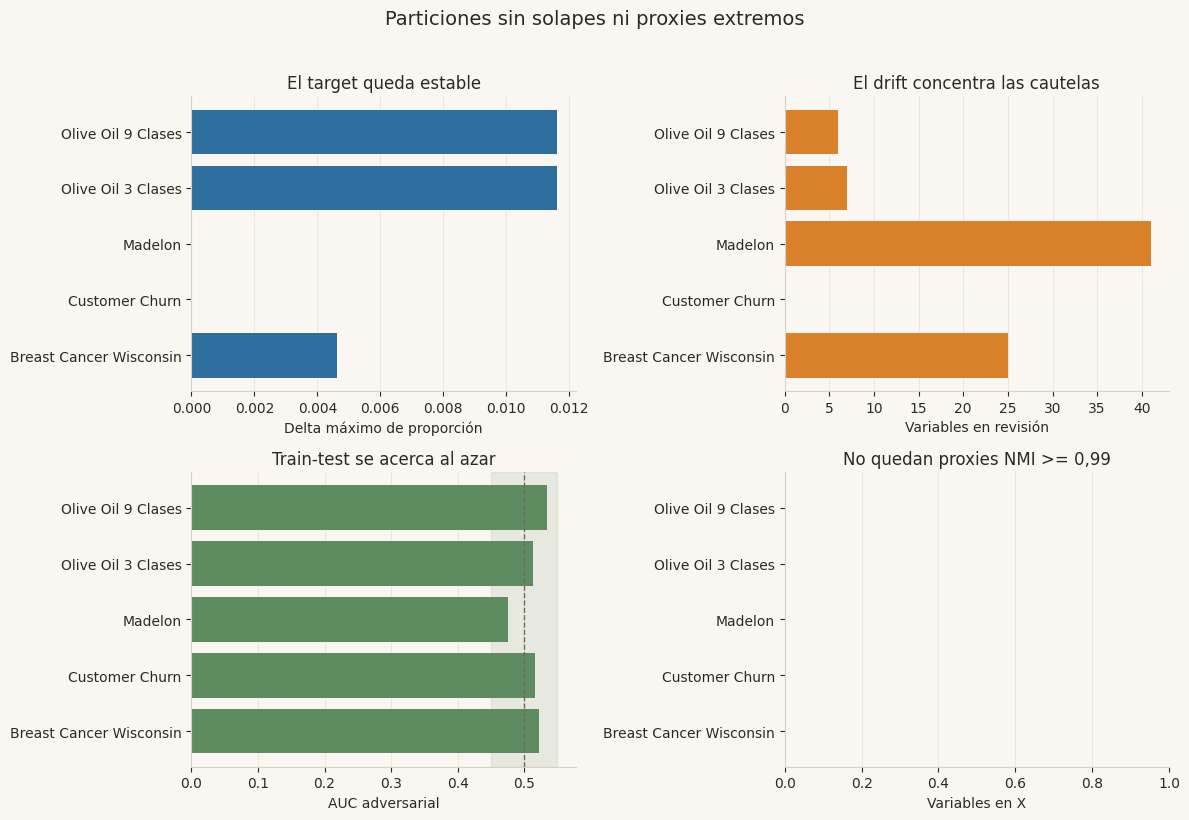

In [104]:
figura, ejes = plt.subplots(2, 2, figsize=(12.0, 8.0))
ejes = ejes.ravel()
labels = resumen_fase5["dataset"].map(etiqueta_dataset)

ejes[0].barh(labels, resumen_fase5["max_delta_target"], color="#2F6F9F")
ejes[0].set_title("El target queda estable")
ejes[0].set_xlabel("Delta máximo de proporción")

ejes[1].barh(labels, resumen_fase5["variables_con_flag"], color="#D9822B")
ejes[1].set_title("El drift concentra las cautelas")
ejes[1].set_xlabel("Variables en revisión")

ejes[2].barh(labels, resumen_fase5["auc_cv"], color="#5E8C61")
ejes[2].axvspan(0.45, 0.55, color="#5E8C61", alpha=0.12)
ejes[2].axvline(0.5, color="#6F6A60", linestyle="--", linewidth=1)
ejes[2].set_title("Train-test se acerca al azar")
ejes[2].set_xlabel("AUC adversarial")

ejes[3].barh(labels, resumen_fase5["nmi_ge_099"], color="#B85C5C")
ejes[3].set_title("No quedan proxies NMI >= 0,99")
ejes[3].set_xlabel("Variables en X")
ejes[3].set_xlim(0, max(1, resumen_fase5["nmi_ge_099"].max() + 1))

for eje in ejes:
    aplicar_estilo_eje(eje, eje_rejilla="x")

figura.suptitle("Particiones sin solapes ni proxies extremos", fontsize=14, y=1.02)
figura.tight_layout()
guardar_figura(figura, "fase4_resumen_metricas_split.png")
plt.show()


El panel comparativo resume la condición final de las particiones: todos los datasets tienen solape total de índices igual a 0 y `nmi_ge_099=0` en las variables que permanecen en `X`. La mayor cautela no procede de leakage, sino de drift: 25 variables marcadas en `breast_cancer_wisconsin`, 41 en `madelon`, 7 en `olive_oil_3class` y 6 en `olive_oil_9class`; `customer_churn` combina 0 señales de revisión, delta de target casi nulo y AUC adversarial 0,516.


## 4.11 Conclusiones de la Auditoría

La Fase 4 deja creados y auditados los splits de cinco datasets operativos. Los puntos que deben permanecer visibles al pasar a selección de características son:

- `customer_churn` conserva variables categóricas en `X`; su codificación debe ajustarse dentro del entrenamiento posterior.
- `madelon` mantiene una dimensionalidad alta, por lo que la selección de características debe evaluar estabilidad y no solo ranking.
- `olive_oil_3class` y `olive_oil_9class` son formulaciones distintas; no deben mezclarse de nuevo como un único dataset.
- `palmitic` queda fuera de las formulaciones de `olive_oil` porque presenta asociación casi perfecta con `target`.
- Las métricas de drift, PCA y validación adversarial son diagnósticos de representatividad del split; no sustituyen la evaluación de modelos posterior.


In [105]:
summary_lines = [
    "# Resultados de la Fase 4 - Creación y Auditoría de Splits",
    "",
    "La Fase 4 crea particiones train/validation/test y audita su estabilidad antes de selección de características.",
    "",
    "## Datasets operativos",
]

for nombre_dataset in DATASET_ORDER:
    summary_lines.append(f"- `{nombre_dataset}`")

summary_lines.extend([
    "",
    "## Conclusión",
    "Las particiones quedan fijadas con solapes nulos, targets conservados y sin proxies extremos dentro de X.",
])

summary_path = PHASE4_REPORTS_DIR / "fase4_resumen_para_memoria.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")


417

La síntesis escrita conserva la conclusión académica de la fase: las particiones quedan fijadas con solapes nulos, targets conservados y sin proxies extremos dentro de `X`. Con ello queda garantizada una base común para comparar la selección clásica y la selección cuántica sin confundir el efecto del método con diferencias de particionado.
